In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
# from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors


import warnings
# Suppress yfinance warnings for cleaner output
warnings.filterwarnings('ignore')

import seaborn as sns
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.stats

from itertools import combinations
from scipy.linalg import solve_triangular
from scipy.stats import t
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm, gaussian_kde
from sklearn.metrics import mean_squared_error, r2_score
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson, jarque_bera

# Distance filtering network construction

In [2]:
tickers = [
    'NVDA', 'TSLA', 'INTC', 'LCID', 'SOFI', 'F', 'PLTR', 'AAL', 'MRVL', 'QBTS',
    'RIOT', 'AMD', 'PCG', 'OSCR', 'WBD', 'AAPL', 'AMZN', 'QUBT', 'HIMS', 'SMCI',
    'BAC', 'PFE', 'MARA', 'COIN', 'ACHR', 'HOOD', 'GOOG', 'CLF', 'AVGO', 'RGTI',
    'GOOGL', 'APLD', 'HL', 'T', 'SNAP', 'AUR', 'CLSK', 'UBER', 'HBAN', 'WFC',
    'SOUN', 'GNW', 'AGNC', 'MRK', 'CSCO', 'ASTS', 'PYPL', 'JOBY', 'MU', 'CCL',
    'MP', 'VZ', 'RKLB', 'IONQ', 'LYFT', 'XOM', 'MSFT', 'SLB', 'AES', 'QXO',
    'ADT', 'CMCSA', 'RIVN', 'KO', 'HAL', 'BMY', 'PTEN', 'OXY', 'PTON', 'ORCL',
    'V', 'OKLO', 'C', 'ENPH', 'NKE'
]

market_ticker = 'SPY'  # SPDR S&P 500 ETF Trust (SPY), used for market features and as a common node in the network

# Formation window: used to build the network
start_date = '2022-04-29'
end_date = '2022-12-31'

# If too many missing continuous features, drop stock
max_missing_frac = 0.30

In [3]:
# Download (close) price/volume data for the formation window

all_tickers = tickers + [market_ticker]

raw = yf.download(
    all_tickers,
    start=start_date,
    end='2023-01-01',  # yfinance end date is exclusive
    auto_adjust=True,
    progress=False
)

close = raw['Close'].copy()
volume = raw['Volume'].copy()

close = close.dropna(axis=1, how='all')
volume = volume.dropna(axis=1, how='all')

available_tickers = [t for t in tickers if t in close.columns]

if market_ticker not in close.columns:
    raise ValueError(f'{market_ticker} data not available.')

print(f'Number of stock tickers with some price data: {len(available_tickers)}')

Number of stock tickers with some price data: 75


In [4]:
# Compute the log-return for the formation window

prices = close[available_tickers + [market_ticker]].copy()
log_returns = np.log(prices / prices.shift(1)).dropna(how='all')

# Prepare node features: stock returns, volume, and market returns as a common node feature
stock_returns = log_returns[available_tickers].copy()
stock_volume = volume[available_tickers].reindex(stock_returns.index)
market_returns = log_returns[market_ticker].copy()  # SPY market returns as a common node feature

In [5]:
# Helper functions for financial metrics

def downside_std(x):
    x = pd.Series(x).dropna()
    x_neg = x[x < 0]
    if len(x_neg) < 2:
        return np.nan
    return np.std(x_neg, ddof=1)

def max_drawdown(return_series):
    return_series = pd.Series(return_series).dropna()
    if len(return_series) < 2:
        return np.nan
    wealth = return_series / return_series.iloc[0]
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    return drawdown.min()  # extract min for trough value to match the definition of MDD

def beta_and_idio(stock_ret, market_ret):
    '''Calculate beta, idiosyncratic volatility, and correlation between a stock and the market.'''
    df = pd.concat([stock_ret, market_ret], axis=1).dropna()
    if len(df) < 10:
        return np.nan, np.nan, np.nan

    r_i = df.iloc[:, 0].values  # stock returns
    r_m = df.iloc[:, 1].values  # market returns

    var_m = np.var(r_m, ddof=1)  # sample variance of market returns
    if var_m == 0:
        return np.nan, np.nan, np.nan

    cov_im = np.cov(r_i, r_m, ddof=1)[0, 1]  # covariance between stock and market returns
    beta = cov_im / var_m  # beta coefficient
    corr = np.corrcoef(r_i, r_m)[0, 1]  # correlation coefficient

    # Calculate idiosyncratic volatility as the standard deviation of residuals
    residuals = r_i - beta * r_m  # residuals from the market model, there might be a constant, but it would not affect the std
    idio_vol = np.std(residuals, ddof=1)

    return beta, idio_vol, corr

In [6]:
# Build continuous formation window features

continuous_rows = []

for ticker in available_tickers:
    r = stock_returns[ticker].dropna()
    p = prices[ticker].dropna()
    v = stock_volume[ticker].dropna()

    beta, idio_vol, corr_spy = beta_and_idio(r, market_returns)

    log_v = np.log(v.replace(0, np.nan)).dropna()

    row = {
        'ticker': ticker,
        'mean_return': r.mean(),  # return-momentum feature 1
        'mean_abs_return': np.abs(r).mean(),  # return-momentum feature 2
        'momentum': r.sum(),  # return-momentum feature 3
        
        'hist_vol': r.std(ddof=1),  # risk and tail behavior feature 1
        'downside_vol': downside_std(r),  # risk and tail behavior feature 2
        'max_drawdown': max_drawdown(p),  # risk and tail behavior feature 3

        'beta_spy': beta,  # Systematic and idiosyncratic risk feature 1
        'idio_vol': idio_vol,  # Systematic and idiosyncratic risk feature 2
        'corr_spy': corr_spy,  # Systematic and idiosyncratic risk feature 3

        'avg_log_volume': log_v.mean() if len(log_v) > 0 else np.nan,  # liquidity and trading activity feature 1
        'vol_log_volume': log_v.std(ddof=1) if len(log_v) > 1 else np.nan,  # liquidity and trading activity feature 2
        
    }

    continuous_rows.append(row)

continuous_df = pd.DataFrame(continuous_rows).set_index('ticker')

# Drop names with too many missing continuous features
missing_frac = continuous_df.isna().mean(axis=1)
continuous_df = continuous_df.loc[missing_frac <= max_missing_frac].copy()

# Fill remaining missing values columnwise by median
continuous_df = continuous_df.apply(lambda col: col.fillna(col.median()), axis=0)

print('Continuous feature matrix shape:', continuous_df.shape)
continuous_df.head()

Continuous feature matrix shape: (75, 11)


,mean_return,mean_abs_return,momentum,hist_vol,downside_vol,max_drawdown,beta_spy,idio_vol,corr_spy,avg_log_volume,vol_log_volume
ticker,,,,,,,,,,,
NVDA,-0.001406,0.030746,-0.237564,0.039172,0.025106,-0.447590,2.077222,0.021287,0.839453,20.086819,0.252755
TSLA,-0.005072,0.031451,-0.857107,0.041698,0.030518,-0.656421,1.706822,0.031760,0.647981,18.267831,0.311092
INTC,-0.002775,0.018221,-0.468994,0.024479,0.016071,-0.452241,1.210280,0.015236,0.782689,17.442760,0.301516
LCID,-0.005760,0.038469,-0.973482,0.050012,0.034503,-0.711359,1.883156,0.040156,0.596077,14.480362,0.394100
SOFI,-0.001677,0.036646,-0.283334,0.049444,0.027371,-0.477521,1.879087,0.039495,0.601623,17.458340,0.442857


In [7]:
# Download categorical data: stock sector and industry

def get_sector_industry(ticker):
    sector = np.nan
    industry = np.nan

    try:
        tk = yf.Ticker(ticker)

        # Try fast_info? Usually no sector/industry there, so use info
        info = tk.info

        if isinstance(info, dict):
            sector = info.get('sector', np.nan)
            industry = info.get('industry', np.nan)

    except Exception:
        pass

    return {
        'ticker': ticker,
        'sector': sector,
        'industry': industry
    }

categorical_rows = []
kept_tickers = continuous_df.index.tolist()

for i, ticker in enumerate(kept_tickers):
    categorical_rows.append(get_sector_industry(ticker))

    # slight pause to reduce request pressure
    if (i + 1) % 10 == 0:
        time.sleep(1)

categorical_df = pd.DataFrame(categorical_rows).set_index('ticker')

# Fill missing values explicitly
categorical_df['sector'] = categorical_df['sector'].fillna('UnknownSector')
categorical_df['industry'] = categorical_df['industry'].fillna('UnknownIndustry')

print('Categorical feature matrix shape:', categorical_df.shape)
categorical_df.head()

Categorical feature matrix shape: (75, 2)


,sector,industry
ticker,,
NVDA,Technology,Semiconductors
TSLA,Consumer Cyclical,Auto Manufacturers
INTC,Technology,Semiconductors
LCID,Consumer Cyclical,Auto Manufacturers
SOFI,Financial Services,Credit Services


In [8]:
# One-hot encode categorical features

categorical_onehot = pd.get_dummies(
    categorical_df,
    columns=['sector', 'industry'],
    drop_first=False,
    dtype=float
)

print('One-hot categorical matrix shape:', categorical_onehot.shape)
categorical_onehot.head()

One-hot categorical matrix shape: (75, 53)


,sector_Basic Materials,sector_Communication Services,sector_Consumer Cyclical,sector_Consumer Defensive,sector_Energy,sector_Financial Services,sector_Healthcare,sector_Industrials,sector_Real Estate,sector_Technology,...,industry_Semiconductors,industry_Software - Application,industry_Software - Infrastructure,industry_Solar,industry_Steel,industry_Telecom Services,industry_Travel Services,industry_Utilities - Diversified,industry_Utilities - Independent Power Producers,industry_Utilities - Regulated Electric
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TSLA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
INTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LCID,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SOFI,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Standardize continuous features, Z-score normalization (mean=0, std=1) to put them on a comparable scale for distance calculations

scaler = StandardScaler()
X_cont = scaler.fit_transform(continuous_df.values)

X_cont_df = pd.DataFrame(
    X_cont,
    index=continuous_df.index,
    columns=continuous_df.columns
)

# Categorical block
X_cat_df = categorical_onehot.loc[continuous_df.index].copy()
X_cat = X_cat_df.values.astype(float)

# Optional weighting of categorical block
# X_cat_weighted = np.sqrt(categorical_weight) * X_cat

# Final combined feature matrix
# X_combined = np.hstack([X_cont, X_cat_weighted])
X_combined = np.hstack([X_cont, X_cat])

combined_columns = (
    [f'cont__{c}' for c in X_cont_df.columns] +
    [f'cat__{c}' for c in X_cat_df.columns]
)

X_combined_df = pd.DataFrame(
    X_combined,
    index=continuous_df.index,
    columns=combined_columns
)

print('Combined feature matrix shape:', X_combined_df.shape)


X_combined_df.head()

Combined feature matrix shape: (75, 64)


,cont__mean_return,cont__mean_abs_return,cont__momentum,cont__hist_vol,cont__downside_vol,cont__max_drawdown,cont__beta_spy,cont__idio_vol,cont__corr_spy,cont__avg_log_volume,...,cat__industry_Semiconductors,cat__industry_Software - Application,cat__industry_Software - Infrastructure,cat__industry_Solar,cat__industry_Steel,cat__industry_Telecom Services,cat__industry_Travel Services,cat__industry_Utilities - Diversified,cat__industry_Utilities - Independent Power Producers,cat__industry_Utilities - Regulated Electric
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,0.177200,0.098441,0.177200,-0.029637,-0.115406,-0.034067,1.030127,-0.508302,1.337009,2.179291,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TSLA,-0.931442,0.147007,-0.931442,0.088633,0.196135,-0.996708,0.464812,-0.002374,0.289848,1.232122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
INTC,-0.236933,-0.764335,-0.236933,-0.717598,-0.635515,-0.055506,-0.293024,-0.800659,1.026564,0.802498,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LCID,-1.139688,0.630413,-1.139688,0.477900,0.425547,-1.249954,0.733938,0.403267,0.005984,-0.740059,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SOFI,0.095296,0.504866,0.095296,0.451300,0.014964,-0.172041,0.727728,0.371323,0.036316,0.810610,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Compute pairwise distance matrix using Euclidean as the metric
# this pairwise distance matrix reflects the overall dissimilarity between stocks based on both continuous and categorical features

dist_matrix = pairwise_distances(X_combined_df, metric='euclidean')
tickers_kept = continuous_df.index.tolist()
n = len(tickers_kept)

dist_df = pd.DataFrame(dist_matrix, index=tickers_kept, columns=tickers_kept)
dist_df.head()

,NVDA,TSLA,INTC,LCID,SOFI,F,PLTR,AAL,MRVL,QBTS,...,BMY,PTEN,OXY,PTON,ORCL,V,OKLO,C,ENPH,NKE
NVDA,0.000000,3.179119,2.384800,4.606925,3.048572,2.690759,2.570752,2.812491,2.133176,9.767431,...,5.515568,4.324722,4.038944,4.554239,4.006012,4.214676,11.277531,3.621646,4.135456,3.427417
TSLA,3.179119,0.000000,3.156375,2.208025,2.780687,2.662904,2.473339,2.804774,3.027530,7.716605,...,5.400595,3.848684,4.229846,3.080146,4.653919,4.752609,10.755536,4.191134,4.705186,3.528891
INTC,2.384800,3.156375,0.000000,4.192998,3.355834,2.337006,2.872827,2.340054,1.973868,8.754291,...,4.067363,3.856761,3.354376,5.064787,2.621280,2.887647,9.835491,2.513195,3.911719,2.536194
LCID,4.606925,2.208025,4.192998,0.000000,3.291100,3.895532,3.045670,3.647630,3.432295,6.578680,...,5.996105,3.646637,4.844999,2.473640,5.258865,5.381536,10.272342,5.022708,4.756122,4.085653
SOFI,3.048572,2.780687,3.355834,3.291100,0.000000,2.949575,2.172052,2.569168,2.800021,8.078415,...,4.955478,2.819251,3.294498,3.178666,4.026814,3.797448,10.052024,3.462167,3.318937,3.220703



Building k-NN Network...
k-NN Graph created with 75 nodes and 350 edges.


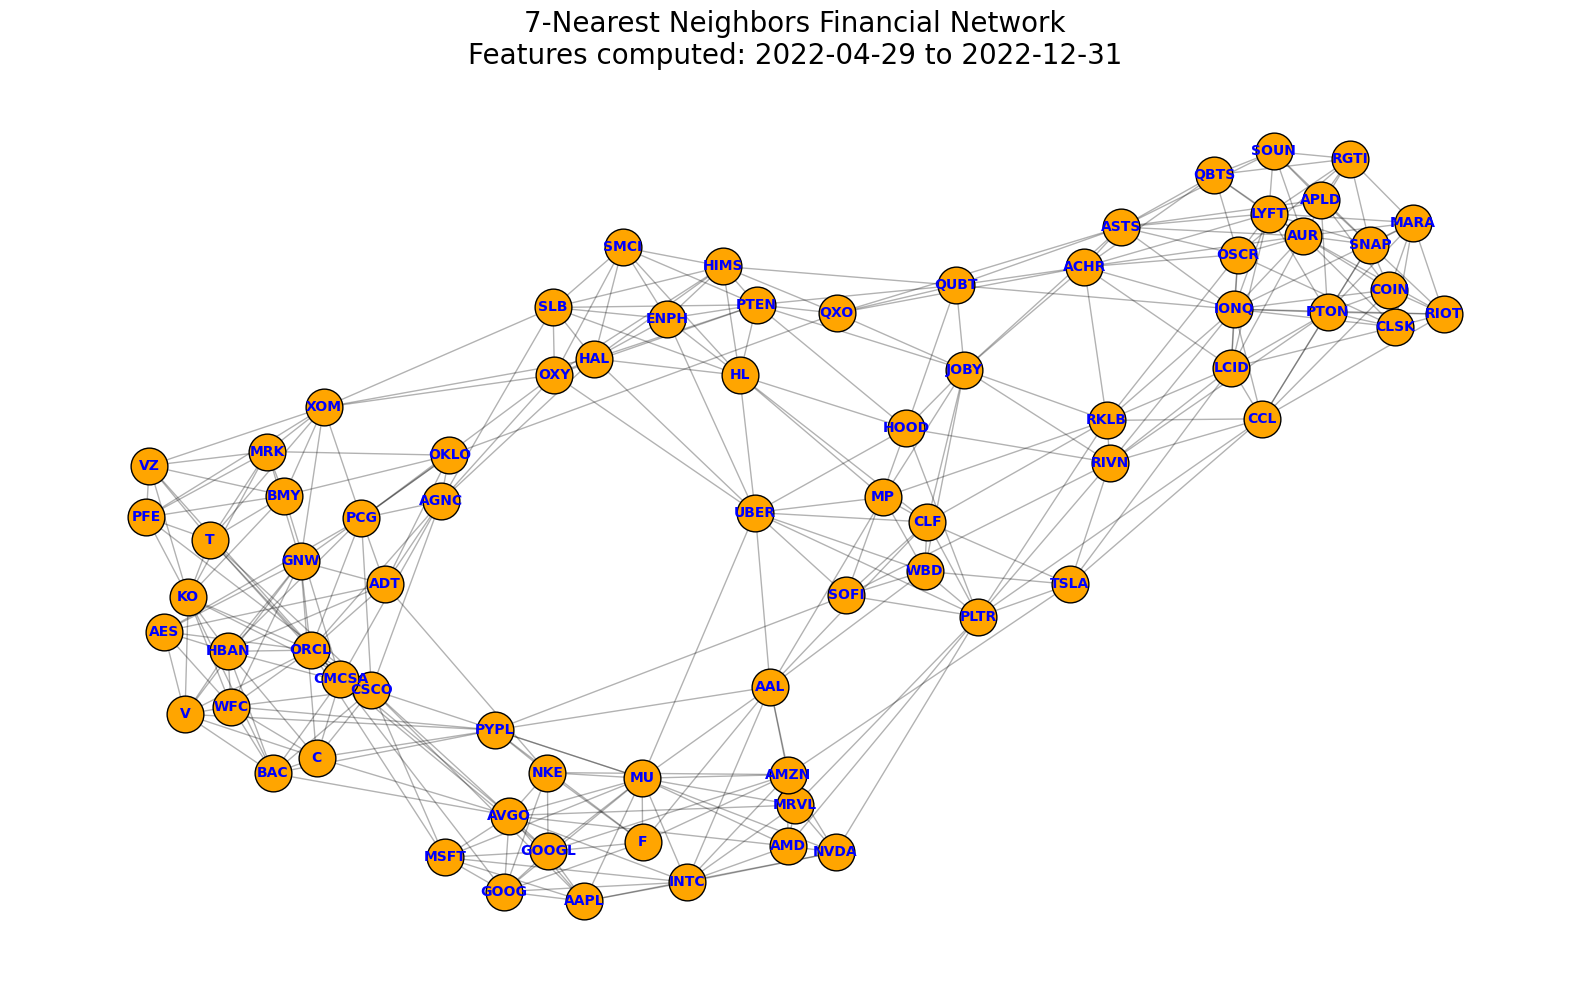

Binary/unweighted adjacency:
[[0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [11]:
# -------------------------------
# Build k-NN Network
# -------------------------------
print('\nBuilding k-NN Network...')
k_neighbors = 7

# We use k_neighbors + 1 because a node is always its own closest neighbor (distance 0)
knn = NearestNeighbors(n_neighbors=k_neighbors + 1, metric='precomputed')
knn.fit(dist_matrix)
knn_distances, knn_indices = knn.kneighbors(dist_matrix)

G = nx.Graph()
node_names = dist_df.index.tolist()

# Add all nodes explicitly
G.add_nodes_from(node_names)

# Add edges based on the k nearest neighbors
for i in range(len(node_names)):
    stock_A = node_names[i]
    # Start loop at 1 to skip the stock connecting to itself
    for j in range(1, k_neighbors + 1):
        neighbor_idx = knn_indices[i, j]
        stock_B = node_names[neighbor_idx]
        distance = knn_distances[i, j]
        # similarity = 1 / (1 + distance)  # similarity in (0, 1], higher means more similar
        
        # Add edge (networkx will handle duplicate undirected edges automatically)
        G.add_edge(stock_A, stock_B, weight=distance)
        # G_knn.add_edge(stock_A, stock_B)  # add an weightless edge for simplicity, between similar stocks (in the same kNN cluster)

print(f'k-NN Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')

# -------------------------------
# Plot the Network
# -------------------------------
plt.figure(figsize=(16, 10))

# Spring layout works very well for k-NN networks
pos = nx.spring_layout(G, seed=0) 

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='orange', edgecolors='black')
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='blue', font_weight='bold')

plt.title(f'{k_neighbors}-Nearest Neighbors Financial Network\nFeatures computed: {start_date} to {end_date}', fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.show()

A = nx.to_numpy_array(G, nodelist=node_names, weight=None, dtype=int)
print('Binary/unweighted adjacency:')
print(A)

---

# Network necessary quantities for evaluation

In [12]:
def r_stage_node_weight_matrix(G, r, dist_df=None, sim_df=None, mode='equal', nodelist=None):
    """
    Compute the r-stage node weight matrix W^(r).

    Parameters
    ----------
    G : nx.Graph
        Undirected graph defining the neighbourhood structure.
    r : int
        Neighbourhood stage.
    dist_df : pd.DataFrame, optional
        Full pairwise distance matrix indexed by node names.
        Required when mode='distance'.
    sim_df : pd.DataFrame, optional
        Full pairwise similarity matrix indexed by node names.
        Required when mode='similarity'.
    mode : {'equal', 'distance', 'similarity'}
        Weighting scheme.
    nodelist : list, optional
        Node ordering. If None, uses sorted(G.nodes()).

    Returns
    -------
    W_r : pd.DataFrame
        r-stage row-normalized weight matrix.
    """

    if nodelist is None:
        nodelist = sorted(G.nodes())

    d = len(nodelist)
    idx = {node: i for i, node in enumerate(nodelist)}
    W_r = np.zeros((d, d), dtype=float)

    # shortest-path stage in the unweighted graph:
    # this determines N_r(i)
    spl = dict(nx.all_pairs_shortest_path_length(G, cutoff=r))

    for i, u in enumerate(nodelist):
        neigh_r = [v for v, hop in spl.get(u, {}).items() if hop == r]

        if len(neigh_r) == 0:
            continue

        if mode == 'equal':
            weights = np.ones(len(neigh_r), dtype=float) / len(neigh_r)

        elif mode == 'distance':
            if dist_df is None:
                raise ValueError("dist_df must be provided when mode='distance'.")
            vals = np.array([1.0 / dist_df.loc[u, v] for v in neigh_r], dtype=float)
            weights = vals / vals.sum()

        elif mode == 'similarity':
            if sim_df is None:
                raise ValueError("sim_df must be provided when mode='similarity'.")
            vals = np.array([sim_df.loc[u, v] for v in neigh_r], dtype=float)
            total = vals.sum()
            weights = vals / total if total > 0 else np.ones(len(neigh_r)) / len(neigh_r)

        else:
            raise ValueError("mode must be one of {'equal', 'distance', 'similarity'}.")

        for v, w in zip(neigh_r, weights):
            j = idx[v]
            W_r[i, j] = w

    return W_r

In [13]:
def node_weight_matrix(G, dist_df=None, sim_df=None, mode='equal', nodelist=None):
    """
    Generate the overall node weight matrix W = sum_r W^(r)
    over all non-zero r-stage weight matrices.
    """

    if nodelist is None:
        nodelist = sorted(G.nodes())

    d = len(nodelist)
    W_total = np.zeros((d, d), dtype=float)

    # graph diameter gives the largest possible non-empty stage
    if nx.is_connected(G):
        max_r = nx.diameter(G)
    else:
        # for disconnected graphs, use max diameter over connected components
        max_r = max(nx.diameter(G.subgraph(c).copy()) for c in nx.connected_components(G))

    for r in range(1, max_r + 1):
        W_r = r_stage_node_weight_matrix(
            G, r, dist_df=dist_df, sim_df=sim_df, mode=mode, nodelist=nodelist
        )
        if np.any(W_r):
            W_total += W_r

    return W_total

In [14]:
node_names = dist_df.index.tolist()

W1 = r_stage_node_weight_matrix(
    G,
    r=1,
    dist_df=dist_df,
    mode='distance',
    nodelist=node_names
)

# W2 = r_stage_node_weight_matrix(
#     G,
#     r=2,
#     dist_df=dist_df,
#     mode='distance',
#     nodelist=node_names
# )

W_total = node_weight_matrix(
    G,
    dist_df=dist_df,
    mode='distance',
    nodelist=node_names
)

W_total_unweighted = node_weight_matrix(
    G,
    mode='equal',
    nodelist=node_names
)

In [15]:
W_tot = np.zeros((len(tickers), len(tickers)))

for r in range(1, 10):
    print(f'Is the {r}-stage node weight matrix a zero matrix?', 
          np.all(r_stage_node_weight_matrix(G, r, dist_df, mode='distance', nodelist=node_names) == np.zeros((len(tickers), len(tickers)))))
    W_tot += r_stage_node_weight_matrix(G, r, dist_df, mode='distance', nodelist=node_names)

# Since we already achieve zero matrix for r > 7, then we expect W_tot == W_total to show our function is valid
np.all(W_tot == W_total)

Is the 1-stage node weight matrix a zero matrix? False
Is the 2-stage node weight matrix a zero matrix? False
Is the 3-stage node weight matrix a zero matrix? False
Is the 4-stage node weight matrix a zero matrix? False
Is the 5-stage node weight matrix a zero matrix? False
Is the 6-stage node weight matrix a zero matrix? False
Is the 7-stage node weight matrix a zero matrix? True
Is the 8-stage node weight matrix a zero matrix? True
Is the 9-stage node weight matrix a zero matrix? True


True

---

# Training estimation period and data preprocessing

This part involves:

1. Check for first-order stationarity.

2. Check for the potential spurious relationship.

3. Demean process.

In [16]:
# Fetch daily closing prices
data = yf.download(
    tickers=tickers,
    start='2023-01-01',
    end='2025-08-01',
    interval='1d',
    group_by='ticker'
)

# Create clean DataFrame
closing_prices = pd.DataFrame({
    t: data[t]['Close'] for t in tickers
}).dropna()

# Calculate the daily log returns (trade working days)
log_returns = np.log(closing_prices).diff().dropna()
log_returns

[*********************100%***********************]  75 of 75 completed


,NVDA,TSLA,INTC,LCID,SOFI,F,PLTR,AAL,MRVL,QBTS,...,BMY,PTEN,OXY,PTON,ORCL,V,OKLO,C,ENPH,NKE
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-04,0.029867,0.049979,0.034924,0.049022,0.058269,0.027862,0.029300,0.064588,0.017080,-0.110001,...,0.004970,0.037504,0.000982,0.084957,0.009037,0.024859,0.000502,0.025449,-0.006615,0.020504
2023-01-05,-0.033366,-0.029469,-0.004345,-0.036139,-0.029789,0.019786,-0.040315,0.029009,-0.052518,-0.114880,...,-0.001806,0.024842,0.018001,-0.029853,-0.002014,-0.007080,0.001504,-0.004482,-0.045820,-0.004879
2023-01-06,0.040797,0.024352,0.041576,0.017447,-0.002162,0.026582,0.012579,0.013490,0.040130,-0.044452,...,0.014905,0.010122,0.024293,0.038862,0.015886,0.030968,0.001002,0.011908,-0.028355,0.031901
2023-01-09,0.050458,0.057655,0.019987,0.063949,0.042379,0.008706,0.015504,0.029874,0.022461,-0.046520,...,-0.027639,0.012949,0.005163,0.044939,0.012576,0.003896,0.002000,0.004850,-0.024742,0.002566
2023-01-10,0.017821,-0.007711,0.004425,0.058714,0.060380,0.011751,0.030305,0.038931,0.002435,0.055570,...,0.008972,0.028820,0.001092,0.049147,0.000925,0.011326,-0.001000,0.013580,0.008257,0.007898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,-0.001382,0.034637,-0.089143,-0.023690,-0.014517,0.018478,0.025124,0.003484,0.002293,-0.046086,...,-0.010476,-0.029952,0.001791,0.020016,0.009386,0.008636,0.012126,0.007103,-0.003102,0.011207
2025-07-28,0.018559,0.029707,-0.000967,-0.045542,-0.008527,-0.016704,-0.005810,0.006932,0.022650,-0.027944,...,-0.019179,0.052644,0.018613,-0.027822,0.010511,-0.004407,0.000000,-0.005427,-0.013076,0.038202
2025-07-29,-0.007040,-0.013575,-0.013142,-0.086034,0.063587,-0.017890,-0.010442,-0.013913,0.005649,-0.037761,...,-0.013776,0.017475,-0.001978,-0.031850,0.009122,-0.011829,-0.061312,-0.011261,-0.042970,-0.011550


#### 1. Check for (first-order) stationarity/near-stationarity for log-return series.

In [17]:
adf_statistic_list = []

for ticker in tickers:
    adf_statistic_list.append(adfuller(log_returns[ticker].to_numpy())[1])
    
if all(x < 0.05 for x in adf_statistic_list):
    print('All log-return series are (near) stationary, via ADF test.')
else:
    print('Exist non-stationary return series.')

All log-return series are (near) stationary, via ADF test.


#### 2. Check for spurious relationship, by computing the $R^2$ and $d$ for pairwise stock's log-return.

In [18]:
results = []

for i, stock_i in enumerate(tickers):
    for stock_j in tickers[i+1:]:
        y = log_returns[stock_i].dropna()
        x = log_returns[stock_j].reindex(y.index).dropna()
        y = y.reindex(x.index)
        
        X = sm.add_constant(x)
        model = sm.OLS(y, X).fit()
        
        results.append({
            'dependent_stock': stock_i,
            'regressor_stock': stock_j,
            'R2': model.rsquared,
            'DW': durbin_watson(model.resid)
        })

df_stats = pd.DataFrame(results)  # have length 2775 = 75 * (75-1)/2

# Add a new column for checking spurious regression via R^2 > d
df_stats['spurious'] = df_stats['R2'] > df_stats['DW']

# 1) Check if there is at least one True in the column
spurious_reg = df_stats['spurious'].any()
print('Do we have any spurious regressions?', spurious_reg)

# 2) If so, count how many
num_spur = df_stats['spurious'].sum()
print(f'Number of spurious pairs: {num_spur} out of {len(df_stats)}')

Do we have any spurious regressions? False
Number of spurious pairs: 0 out of 2775


#### 3. Demean

In [19]:
# Center the log-returns
log_returns_demean = log_returns - log_returns.mean()
log_returns_demean

,NVDA,TSLA,INTC,LCID,SOFI,F,PLTR,AAL,MRVL,QBTS,...,BMY,PTEN,OXY,PTON,ORCL,V,OKLO,C,ENPH,NKE
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-04,0.025959,0.048354,0.035332,0.050447,0.055768,0.027613,0.024324,0.064748,0.015817,-0.113845,...,0.005578,0.038891,0.001432,0.085156,0.007263,0.024038,-0.002661,0.024189,-0.003424,0.021159
2023-01-05,-0.037274,-0.031094,-0.003936,-0.034713,-0.032290,0.019537,-0.045292,0.029169,-0.053781,-0.118725,...,-0.001197,0.026229,0.018451,-0.029654,-0.003789,-0.007901,-0.001659,-0.005742,-0.042630,-0.004225
2023-01-06,0.036889,0.022727,0.041985,0.018873,-0.004663,0.026334,0.007602,0.013650,0.038867,-0.048296,...,0.015514,0.011509,0.024743,0.039061,0.014111,0.030148,-0.002161,0.010647,-0.025165,0.032556
2023-01-09,0.046550,0.056030,0.020396,0.065374,0.039879,0.008457,0.010527,0.030034,0.021198,-0.050365,...,-0.027030,0.014336,0.005613,0.045138,0.010802,0.003076,-0.001163,0.003589,-0.021552,0.003221
2023-01-10,0.013913,-0.009336,0.004834,0.060140,0.057880,0.011502,0.025328,0.039091,0.001172,0.051725,...,0.009581,0.030207,0.001542,0.049347,-0.000849,0.010506,-0.004162,0.012320,0.011448,0.008553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,-0.005290,0.033013,-0.088734,-0.022264,-0.017017,0.018229,0.020147,0.003644,0.001030,-0.049931,...,-0.009867,-0.028566,0.002241,0.020215,0.007612,0.007815,0.008964,0.005843,0.000089,0.011862
2025-07-28,0.014651,0.028082,-0.000558,-0.044116,-0.011028,-0.016953,-0.010787,0.007093,0.021386,-0.031788,...,-0.018571,0.054030,0.019064,-0.027623,0.008737,-0.005227,-0.003163,-0.006688,-0.009886,0.038856
2025-07-29,-0.010948,-0.015200,-0.012733,-0.084609,0.061086,-0.018138,-0.015419,-0.013753,0.004386,-0.041606,...,-0.013167,0.018861,-0.001528,-0.031650,0.007348,-0.012649,-0.064475,-0.012522,-0.039780,-0.010896


---

# DCC-GNGARCH model class setting

#### DCC-GNGARCH model training and parameter estimation

In [20]:
class DCC_GNGARCH(nn.Module):
    def __init__(self, d, W, S, device, Q_bar=None, init_params=None):
        super().__init__()
        self.d = d
        self.device = device

        W_s = W * S
        self.register_buffer('W_s', W_s)

        if Q_bar is None:
            Q_bar = torch.eye(d, dtype=torch.float32, device=device)
        self.register_buffer('Q_bar', Q_bar)

        # cap for GNGARCH persistence parameters (very close to 1 to avoid instability)
        self.garch_sum_cap = 0.99999

        if init_params is None:
            # alpha0
            init_alpha0 = torch.tensor([0.05], dtype=torch.float32, device=device)
            init_log_alpha0 = torch.log(init_alpha0)

            # relative proportions of alpha1, gamma1, beta11, delta11
            init_garch_mix = torch.log(torch.tensor(
                [0.20, 0.60, 0.05, 0.05],
                dtype=torch.float32, device=device
            ))

            # DCC weights: lambda, omega, remainder
            init_dcc_vals = torch.tensor([0.4, 0.3, 0.3],
                                         dtype=torch.float32, device=device)
            init_log_dcc_params = torch.log(init_dcc_vals)

            init_params = torch.cat(
                [init_log_alpha0, init_garch_mix, init_log_dcc_params],
                dim=0
            )

        self.params = nn.Parameter(init_params)

    def get_params(self):
        # alpha0 > 0
        alpha0 = torch.exp(self.params[0])

        # alpha1, gamma1, beta11, delta11 > 0 and sum < 1
        garch_weights = torch.softmax(self.params[1:5], dim=0) * self.garch_sum_cap
        alpha1 = garch_weights[0]
        gamma1 = garch_weights[1]
        beta11 = garch_weights[2]
        delta11 = garch_weights[3]

        # lambda, omega > 0 and lambda + omega < 1
        dcc_weights = torch.softmax(self.params[5:8], dim=0)
        lam = dcc_weights[0]
        omega = dcc_weights[1]

        return alpha0, alpha1, gamma1, beta11, delta11, lam, omega

    @staticmethod
    def compute_R_t(Q_t, eps=1e-10):
        """
        Convert Q_t into correlation matrix R_t:
            R_t = diag(Q_t)^(-1/2) Q_t diag(Q_t)^(-1/2)
        """
        q_diag = torch.diag(Q_t)
        q_diag = torch.clamp(q_diag, min=eps)  # numerical safeguard for non-positive diagonal entries
        inv_sqrt_diag = torch.diag(torch.rsqrt(q_diag))  # reciprocal of sqrt of diagonal entries
        R_t = inv_sqrt_diag @ Q_t @ inv_sqrt_diag
        # R_t = 0.5 * (R_t + R_t.T)
        # R_t.fill_diagonal_(1.0)
        return R_t

    @staticmethod
    def compute_Sigma_t(var_t, R_t, eps=1e-10):
        """
        Construct Sigma_t = D_t R_t D_t, where D_t = diag(sqrt(var_t)).
        """
        var_t = torch.clamp(var_t, min=eps)  # numerical safeguard for non-positive variances
        D_t = torch.diag(torch.sqrt(var_t))
        Sigma_t = D_t @ R_t @ D_t
        # Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
        return Sigma_t

    def compute_conditional(self, X_prev, var_prev, Q_prev):
        """
        Compute:
            var_t, Q_t, R_t, Sigma_t

        using DCC(1,1)-GNGARCH(1,1,[1],[1]).
        """
        alpha0, alpha1, gamma1, beta11, delta11, lam, omega = self.get_params()

        # Update conditional variances
        clustering_term = beta11 * (self.W_s @ (X_prev ** 2))
        persistence_term = delta11 * (self.W_s @ var_prev)

        var_t = (
            alpha0
            + alpha1 * (X_prev ** 2)
            + gamma1 * var_prev
            + clustering_term
            + persistence_term
        )
        var_t = torch.clamp(var_t, min=1e-10)  # numerical safeguard for non-positive variances

        # Standardized residual epsilon_{t-1} = D_{t-1}^{-1} X_{t-1}
        eps_prev = X_prev / torch.sqrt(torch.clamp(var_prev, min=1e-10))

        # Update Q_t
        Q_t = (
            (1.0 - lam - omega) * self.Q_bar
            + lam * torch.outer(eps_prev, eps_prev)
            + omega * Q_prev
        )
        # Q_t = 0.5 * (Q_t + Q_t.T)

        # Normalize Q_t to R_t, and then construct Sigma_t
        R_t = self.compute_R_t(Q_t)
        Sigma_t = self.compute_Sigma_t(var_t, R_t)

        return var_t, Q_t, R_t, Sigma_t

    # def ensure_posdef_cholesky(self, Sigma_t, threshold=1e-6):
    #     """
    #     Numerical safeguard for Cholesky.
    #     Ensure covariance matrix is positive definite and not ill-conditioned by adding jitter, 
    #     so we can use Cholesky decomposition.
    #     In theory Sigma_t should already be PD under the DCC construction,
    #     but this protects against numerical issues.
    #     """
    #     # Compute the eigenvalues and check if the matrix is positive definite
    #     min_eigval = torch.min(torch.linalg.eigvalsh(Sigma_t))
    #     jitter = torch.zeros_like(Sigma_t)  # initialise jitter to zero

    #     if min_eigval < threshold:
    #         jitter = (-min_eigval + threshold) * torch.eye(self.d, device=self.device)

    #     L = torch.linalg.cholesky(Sigma_t + jitter)
    #     return L, Sigma_t


    def nll_loss(self, X_data, var0, Q0):
        """
        Compute the negative Log-Likelihood loss (MLE/QMLE),
        Assumes conditional multivariate normal distribution.
        """
        T, d = X_data.shape
        total_nll = 0.0

        var_prev = var0.clone()
        Q_prev = Q0.clone()
        const = d * torch.log(torch.tensor(2.0 * torch.pi, device=self.device))

        for t in range(1, T):
            X_prev, X_curr = X_data[t - 1], X_data[t]

            var_t, Q_t, R_t, Sigma_t = self.compute_conditional(X_prev, var_prev, Q_prev)
            # L, Sigma_t = self.ensure_posdef_cholesky(Sigma_t)
            L = torch.linalg.cholesky(Sigma_t)  # Cholesky decomposition for log-determinant and quadratic form

            # Compute the log-determinant term using Cholesky decomposition L
            log_det = 2.0 * torch.sum(torch.log(torch.diag(L)))

            # Compute the quadratic form: X_curr^T * inv(Sigma) * X_curr
            inv_Sigma_t = torch.cholesky_inverse(L)
            quad = X_curr @ (inv_Sigma_t @ X_curr)

            total_nll += 0.5 * (const + log_det + quad)  # log-likelihood for this time step

            # Update previous values for next iteration
            var_prev, Q_prev = var_t, Q_t

        return total_nll

    # An alternative loss function that computes the MSE
    def mse_loss(self, X_data, var0, Q0):
        """
        Vectorized MSE loss computation, comparing conditional covariance with observed squared returns.
        """
        T, d = X_data.shape
        total_mse = 0.0

        var_prev = var0.clone()
        Q_prev = Q0.clone()

        for t in range(1, T):
            X_prev = X_data[t - 1]
            X_curr = X_data[t]

            var_t, Q_t, R_t, Sigma_t = self.compute_conditional(X_prev, var_prev, Q_prev)

            obs_cov = torch.outer(X_curr, X_curr)
            total_mse = total_mse + torch.mean((obs_cov - Sigma_t) ** 2)

            var_prev = var_t
            Q_prev = Q_t

        return total_mse

    def forward(self, X_data, var0, Q0):
        """
        Simulate one path conditionally using the fitted DCC-GNGARCH recursion.
        """
        T, d = X_data.shape

        X_sim = torch.zeros_like(X_data)
        X_sim[0] = X_data[0]

        var_prev = var0.clone()
        Q_prev = Q0.clone()

        for t in range(1, T):
            X_prev = X_data[t - 1]

            var_t, Q_t, R_t, Sigma_t = self.compute_conditional(X_prev, var_prev, Q_prev)
            # L, Sigma_t = self.ensure_posdef_cholesky(Sigma_t)
            L = torch.linalg.cholesky(Sigma_t)

            Z = torch.randn(d, device=self.device)
            X_sim[t] = L @ Z

            var_prev, Q_prev = var_t, Q_t
        return X_sim

In [21]:
# Model training and parameter fitting
def train(n_epochs, model, data, var0, Q0, method, optimizer):
    loss_history = []
    for epoch in range(1, n_epochs+1):
        optimizer.zero_grad()
        if method == 'nll':
            loss = model.nll_loss(data, var0, Q0)
        elif method == 'mse':
            loss = model.mse_loss(data, var0, Q0)
        else:
            raise ValueError('Method must be either nll or mse.')
        # Store the loss for plotting
        loss_history.append(loss.item())
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: {method} loss = {loss.item():.4f}')
            
    # Extract fitted parameters
    with torch.no_grad():
        alpha0, alpha1, gamma1, beta11, delta11, lam, omega = model.get_params()
    print(f'Fitted parameters via {method}:')
    print(f'alpha0 = {alpha0.item():.4f}')
    print(f'alpha1 = {alpha1.item():.4f}')
    print(f'gamma1 = {gamma1.item():.4f}')
    print(f'beta11 = {beta11.item():.4f}')
    print(f'delta11 = {delta11.item():.4f}')
    print(f'lambda = {lam.item():.4f}')
    print(f'omega = {omega.item():.4f}')

    return loss_history

In [22]:
# Prepare the data & network
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dcc_GNGARCH_data_torch = torch.tensor(log_returns_demean.to_numpy(), dtype=torch.float32).to(device)  # shape (T, d)
T, d = dcc_GNGARCH_data_torch.shape
W_torch = torch.tensor(W_total, dtype=torch.float32).to(device)  # shape (d, d)
S1_torch = torch.tensor(A, dtype=torch.float32).to(device)  # shape (d, d)

# Initial states var0 and Q0 for the recursion, as torch tensors on the same device
# 1. Initial marginal variances from demeaned returns
var0 = torch.var(dcc_GNGARCH_data_torch, dim=0, unbiased=True)
# var0 = torch.clamp(var0, min=1e-8)   # numerical safeguard

# 2. Preliminary standardised residuals using var0
eps0 = dcc_GNGARCH_data_torch / torch.sqrt(var0).unsqueeze(0)   # shape (T, d)

# 3. Long-run DCC target matrix Q_bar
Q_bar = (eps0.T @ eps0) / T
# Q_bar = Q_bar + 1e-6 * torch.eye(d, device=device)   # tiny ridge for stability

# 4. Initial raw DCC covariance
Q0 = Q_bar.clone()

# Instantiate model + optimizer
model = DCC_GNGARCH(d=d,W=W_torch, S=S1_torch, device=device, Q_bar=Q_bar).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [23]:
# Train the model with both mse and nll methods (total 20 min on PC)
# mse_loss_history = train(n_epochs=500, model=model, data=dcc_GNGARCH_data_torch, var0=var0, Q0=Q0, 
#                          method='mse', optimizer=optimizer)
nll_loss_history = train(n_epochs=1000, model=model, data=dcc_GNGARCH_data_torch, var0=var0, Q0=Q0, 
                         method='nll', optimizer=optimizer)  # 500 epochs for 9-10 min (2 min for 100 epochs)

Epoch 100: nll loss = -59686.5195
Epoch 200: nll loss = -77817.2578
Epoch 300: nll loss = -88878.7969
Epoch 400: nll loss = -97520.3750
Epoch 500: nll loss = -101942.7188
Epoch 600: nll loss = -103749.1562
Epoch 700: nll loss = -104886.1719
Epoch 800: nll loss = -105723.3984
Epoch 900: nll loss = -106295.4922
Epoch 1000: nll loss = -106806.0000
Fitted parameters via nll:
alpha0 = 0.0004
alpha1 = 0.4685
gamma1 = 0.1727
beta11 = 0.3504
delta11 = 0.0085
lambda = 0.0959
omega = 0.0319


In [24]:
# model_nll = DCC_GNGARCH(d=d, W=W_torch, S=S1_torch, device=device, Q_bar=Q_bar).to(device)
# optimizer_nll = optim.Adam(model_nll.parameters(), lr=0.01)

# model_mse = DCC_GNGARCH(d=d, W=W_torch, S=S1_torch, device=device, Q_bar=Q_bar).to(device)
# optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.01)

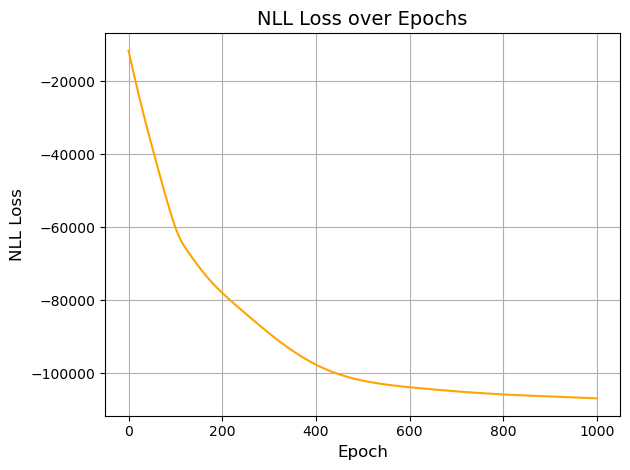

In [25]:
# Plot the training loss history for showing convergence

# Create 2 subplots
# fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# MSE loss convergence
# axes[0].plot(mse_loss_history, label='MSE Loss')
# axes[0].set_xlabel('Epoch', fontsize=12)
# axes[0].set_ylabel('MSE Loss', fontsize=12)
# axes[0].set_title('MSE Loss over Epochs', fontsize=14)
# axes[0].grid()

# NLL loss convergence
plt.plot(nll_loss_history, label='NLL Loss', color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NLL Loss', fontsize=12)
plt.title('NLL Loss over Epochs', fontsize=14)
plt.grid()

plt.tight_layout()
plt.show()

#### Zhou's network GARCH model and parameter estimation

In [ ]:
class network_GARCH_Zhou(nn.Module):
    def __init__(self, d, W, S, device, init_params=None):
        super().__init__()
        self.d = d
        self.device = device
        
        # Compute W_s and create neighbour mask
        W_s = W * S
        self.register_buffer('W_s', W_s)
        
        # Initialize trainable log-parameters
        if init_params is None:
            init_vals = torch.tensor([0.1, 0.3, 0.4, 0.1], 
                                    dtype=torch.float32, device=device)
            init_params = torch.log(init_vals)
        self.params = nn.Parameter(init_params)

    def get_params(self):
        """Return constrained (positive) parameters"""
        alpha0, alpha1, gamma1, beta11 = torch.exp(self.params)
        return alpha0, alpha1, gamma1, beta11

    def compute_conditional(self, X_prev, var_prev, cov_prev):
        """Vectorised computation with proper exclusions"""
        alpha0, alpha1, gamma1, beta11 = self.get_params()
        d = self.d
        
        # Vectorised variance update
        clustering_term = beta11 * (self.W_s @ (X_prev ** 2))
        var_curr = alpha0 + alpha1 * (X_prev ** 2) + gamma1 * var_prev + clustering_term
        
        # Vectorised covariance update (setting diagonal only)
        cov_curr = torch.zeros_like(cov_prev)  # initialisation
        cov_curr[range(d), range(d)] = var_curr  # Set diagonal
        
        return var_curr, cov_curr
    
    def nll_loss(self, X_data, var0, cov0):
        """
        Compute the negative Log-Likelihood loss, which is proportional to QLIKE (invariant to a constant),
        assumes conditional multivariate normal distribution (needed for QLIKE).
        """
        
        T, d = X_data.shape
        total_nll = 0.0

        var_prev, cov_prev = var0.clone(), cov0.clone()
        const = d * torch.log(2 * torch.tensor(torch.pi, device=self.device))

        for t in range(1, T):
            X_prev, X_curr = X_data[t-1], X_data[t]
            var_curr, cov_curr = self.compute_conditional(X_prev, var_prev, cov_prev)
            L = torch.linalg.cholesky(cov_curr)

            # Compute the log-determinant term using Cholesky decomposition L
            log_det = 2.0 * torch.sum(torch.log(torch.diag(L)))
            
            # Compute the quadratic form: X_curr^T * inv(Sigma) * X_curr
            inv_cov_curr = torch.cholesky_inverse(L)
            quad = X_curr @ (inv_cov_curr @ X_curr)
            total_nll += 0.5 * (const + log_det + quad)
            
            # Update previous values for next iteration
            var_prev, cov_prev = var_curr, cov_curr

        return total_nll
    
    # An alternative loss function that computes the MSE
    def mse_loss(self, X_data, var0, cov0):
        """
        Vectorized MSE loss computation, comparing conditional covariance with observed squared returns.
        """
        
        T, d = X_data.shape
        total_mse = 0.0
        var_prev = var0.clone()
        cov_prev = cov0.clone()
        
        for t in range(1, T):
            X_prev = X_data[t-1]
            var_curr, cov_curr = self.compute_conditional(X_prev, var_prev, cov_prev)
            # Compute observed covariance proxy (squared returns)
            obs_cov = torch.outer(X_data[t], X_data[t])
            # Vectorized MSE
            total_mse += torch.mean((cov_curr - obs_cov) ** 2)
            
            # Update state
            var_prev = var_curr
            cov_prev = cov_curr
        return total_mse
    
    def forward(self, X_data, var0, cov0):
        T, d = X_data.shape
        X_sim = torch.zeros_like(X_data)
        var_prev = var0.clone()
        cov_prev = cov0.clone()
        X_sim[0] = X_data[0]
        
        for t in range(1, T):
            X_prev = X_data[t-1]
            var_curr, cov_curr = self.compute_conditional(X_prev, var_prev, cov_prev)
            L = torch.linalg.cholesky(cov_curr)
            
            Z = torch.randn(d, device=self.device)
            X_sim[t] = L @ Z
            # Update the previous values for the next iteration
            var_prev = var_curr
            cov_prev = cov_curr
        return X_sim

In [27]:
def train_Zhou(n_epochs, model, data, var0, cov0, method, optimizer):
    loss_history = []
    for epoch in range(1, n_epochs+1):
        optimizer.zero_grad()
        if method in ('nll', 'qlike'):
            loss = model.nll_loss(data, var0, cov0)
        elif method == 'mse':
            loss = model.mse_loss(data, var0, cov0)
        else:
            raise ValueError('Method must be either nll/qlike or mse.')
        # Store the loss for plotting
        loss_history.append(loss.item())
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: {method} loss = {loss.item():.4f}')
            
    # Extract fitted parameters
    with torch.no_grad():
        alpha0, alpha1, gamma1, beta11 = model.get_params()
    print(f'Fitted parameters via {method}:')
    print(f'alpha0 = {alpha0.item():.4f}')
    print(f'alpha1 = {alpha1.item():.4f}')
    print(f'gamma1 = {gamma1.item():.4f}')
    print(f'beta11 = {beta11.item():.4f}')
    
    return loss_history

In [28]:
# Prepare the data & network
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dcc_GNGARCH_data_torch = torch.tensor(log_returns_demean.to_numpy(), dtype=torch.float32).to(device)  # shape (T, d)
T, d = dcc_GNGARCH_data_torch.shape
W_binary_torch = torch.tensor(W_total_unweighted, dtype=torch.float32).to(device)  # shape (d, d), using equal weights for Zhou's model
S1_torch = torch.tensor(A, dtype=torch.float32).to(device)  # shape (d, d)

# Initial states
var0 = torch.var(dcc_GNGARCH_data_torch, dim=0, unbiased=True)  # initial variances
cov0 = torch.cov(dcc_GNGARCH_data_torch.T)  # initial covariances (identity matrix)

# Instantiate model + optimizer
Zhou_model = network_GARCH_Zhou(d=d, W=W_binary_torch, S=S1_torch, device=device).to(device)
optimizer = optim.Adam(Zhou_model.parameters(), lr=0.01)

In [29]:
nll_loss_history_Zhou = train_Zhou(n_epochs=1000, model=Zhou_model, data=dcc_GNGARCH_data_torch, var0=var0, cov0=cov0, 
                         method='nll', optimizer=optimizer)  # approx. 1 min for 100 epochs

Epoch 100: nll loss = -29055.9453
Epoch 200: nll loss = -52638.6680
Epoch 300: nll loss = -70792.2344
Epoch 400: nll loss = -81650.2422
Epoch 500: nll loss = -86590.8516
Epoch 600: nll loss = -88541.6797
Epoch 700: nll loss = -90218.0234
Epoch 800: nll loss = -91187.1094
Epoch 900: nll loss = -91790.8516
Epoch 1000: nll loss = -92204.3125
Fitted parameters via nll:
alpha0 = 0.0005
alpha1 = 0.4446
gamma1 = 0.0696
beta11 = 0.4521


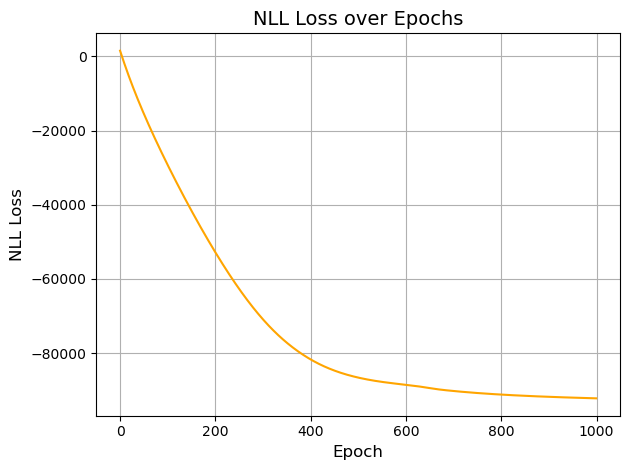

In [30]:
# NLL loss convergence
plt.plot(nll_loss_history_Zhou, label='NLL Loss', color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NLL Loss', fontsize=12)
plt.title('NLL Loss over Epochs', fontsize=14)
plt.grid()

plt.tight_layout()
plt.show()

#### Panel-GARCH(1,1) fitting

In [81]:
class Panel_GARCH(nn.Module):
    """
    Variance-targeted panel GARCH(1,1):
        h_{i,t} = gamma_i (1 - alpha - beta) + alpha * X_{i,t-1}^2 + beta * h_{i,t-1}

    where:
        gamma_i = stock-specific unconditional variance (fixed, estimated by MM),
        alpha, beta = common across all stocks.

    Assumes zero conditional mean / demeaned returns.
    """
    def __init__(self, d, device, gamma, init_params=None):
        super().__init__()
        self.d = d
        self.device = device

        # Fixed stock-specific long-run variances gamma_i
        self.register_buffer('gamma', gamma)

        # Cap for alpha + beta < 1
        self.garch_sum_cap = 0.99999

        if init_params is None:
            # Initial values for alpha, beta, slack
            init_vals = torch.tensor([0.35, 0.45, 0.20],
                                     dtype=torch.float32,
                                     device=device)
            init_params = torch.log(init_vals)

        self.params = nn.Parameter(init_params)

    def get_params(self):
        """
        alpha, beta > 0 and alpha + beta < 1
        using softmax over [alpha, beta, slack].
        """
        weights = torch.softmax(self.params, dim=0) * self.garch_sum_cap
        alpha = weights[0]
        beta = weights[1]
        slack = 1.0 - alpha - beta
        return alpha, beta, slack

    def compute_conditional(self, X_prev, var_prev):
        """
        Compute one-step panel GARCH conditional variances:
            var_t = gamma * (1 - alpha - beta) + alpha * X_prev^2 + beta * var_prev
        """
        alpha, beta, _ = self.get_params()

        omega = self.gamma * (1.0 - alpha - beta)

        var_t = omega + alpha * (X_prev ** 2) + beta * var_prev
        var_t = torch.clamp(var_t, min=1e-10)  # numeric stability

        return var_t

    def compute_Sigma_t(self, var_t):
        """
        Diagonal covariance matrix for the panel GARCH benchmark.
        """
        var_t = torch.clamp(var_t, min=1e-10)
        return torch.diag(var_t)

    def nll_loss(self, X_data, var0):
        """
        Gaussian negative log-likelihood under diagonal covariance:
            X_t | F_{t-1} ~ N(0, diag(var_t))
        """
        T, d = X_data.shape
        total_nll = 0.0

        var_prev = var0.clone()
        const = d * torch.log(torch.tensor(2.0 * torch.pi, device=self.device))

        for t in range(1, T):
            X_prev = X_data[t - 1]
            X_curr = X_data[t]

            var_t = self.compute_conditional(X_prev, var_prev)

            # For diagonal covariance:
            # log|Sigma_t| = sum_i log(var_{i,t})
            log_det = torch.sum(torch.log(var_t))

            # X_t' Sigma_t^{-1} X_t = sum_i X_{i,t}^2 / var_{i,t}
            quad = torch.sum((X_curr ** 2) / var_t)

            total_nll += 0.5 * (const + log_det + quad)

            var_prev = var_t

        return total_nll

    def mse_loss(self, X_data, var0):
        """
        MSE loss comparing conditional variances to squared returns.
        """
        T, d = X_data.shape
        total_mse = 0.0

        var_prev = var0.clone()

        for t in range(1, T):
            X_prev = X_data[t - 1]
            X_curr = X_data[t]

            var_t = self.compute_conditional(X_prev, var_prev)

            total_mse += torch.mean((X_curr ** 2 - var_t) ** 2)

            var_prev = var_t

        return total_mse

    def forecast_variances(self, X_data, var0):
        """
        Return the full path of conditional variance forecasts.
        """
        T, d = X_data.shape
        var_path = torch.zeros_like(X_data)

        var_prev = var0.clone()
        var_path[0] = var_prev

        for t in range(1, T):
            X_prev = X_data[t - 1]
            var_t = self.compute_conditional(X_prev, var_prev)

            var_path[t] = var_t
            var_prev = var_t

        return var_path

    # def one_step_forecast(self, X_prev, var_prev):
    #     """
    #     One-step-ahead variance forecast from the latest state.
    #     """
    #     return self.compute_conditional(X_prev, var_prev)

    def forward(self, X_data, var0):
        """
        Simulate one path conditionally under diagonal covariance.
        """
        T, d = X_data.shape

        X_sim = torch.zeros_like(X_data)
        X_sim[0] = X_data[0]

        var_prev = var0.clone()

        for t in range(1, T):
            X_prev = X_data[t - 1]
            var_t = self.compute_conditional(X_prev, var_prev)

            Z = torch.randn(d, device=self.device)
            X_sim[t] = torch.sqrt(var_t) * Z

            var_prev = var_t

        return X_sim

In [82]:
def train_panel_garch(n_epochs, model, data, var0, method, optimizer):
    loss_history = []

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()

        if method == 'nll':
            loss = model.nll_loss(data, var0)
        elif method == 'mse':
            loss = model.mse_loss(data, var0)
        else:
            raise ValueError("Method must be either 'nll' or 'mse'.")

        loss_history.append(loss.item())
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: {method} loss = {loss.item():.4f}')

    with torch.no_grad():
        alpha, beta, slack = model.get_params()

    print(f'Fitted panel-GARCH parameters via {method}:')
    print(f'alpha = {alpha.item():.4f}')
    print(f'beta  = {beta.item():.4f}')
    print(f'1-alpha-beta = {slack.item():.4f}')

    return loss_history

In [83]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Demeaned returns: shape (T, d)
panel_garch_data_torch = torch.tensor(
    log_returns_demean.to_numpy(),
    dtype=torch.float32
).to(device)

T, d = panel_garch_data_torch.shape

# Pakel-style method-of-moments gamma_i = average squared return, VTE
# Since returns are demeaned, this is essentially the sample variance level
gamma_torch = torch.mean(panel_garch_data_torch ** 2, dim=0)

# Initial variance state: a natural choice is var0 = gamma
var0_panel = gamma_torch.clone()

# Instantiate model
panel_garch_model = Panel_GARCH(
    d=d,
    device=device,
    gamma=gamma_torch
).to(device)

# Optimizer
panel_optimizer = optim.Adam(panel_garch_model.parameters(), lr=0.01)

In [84]:
nll_loss_history_pgarch = train_panel_garch(
    n_epochs=1000,
    model=panel_garch_model,
    data=panel_garch_data_torch,
    var0=var0_panel,
    method='nll',
    optimizer=panel_optimizer
)

Epoch 100: nll loss = -99626.9766
Epoch 200: nll loss = -99684.9062
Epoch 300: nll loss = -99693.7891
Epoch 400: nll loss = -99695.5078
Epoch 500: nll loss = -99695.7422
Epoch 600: nll loss = -99695.7031
Epoch 700: nll loss = -99695.7500
Epoch 800: nll loss = -99695.7188
Epoch 900: nll loss = -99695.7109
Epoch 1000: nll loss = -99695.7266
Fitted panel-GARCH parameters via nll:
alpha = 0.0877
beta  = 0.7528
1-alpha-beta = 0.1596


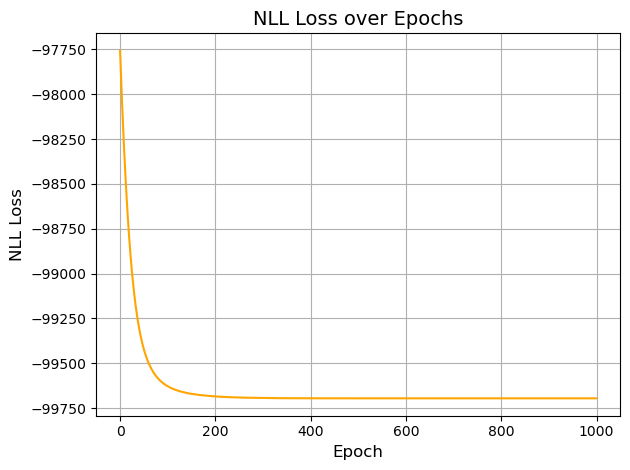

In [85]:
# NLL loss convergence
plt.plot(nll_loss_history_pgarch, label='NLL Loss', color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NLL Loss', fontsize=12)
plt.title('NLL Loss over Epochs', fontsize=14)
plt.grid()

plt.tight_layout()
plt.show()

# Forecast scheme

In [86]:
# ======distance-based network parameters, for DCC-GNGARCH========
# params_nll = {
#     'alpha0': 0.0005,
#     'alpha1': 0.5957,
#     'gamma1': 0.3189,
#     'beta11': 0.0802,
#     'delta11': 0.0052,
#     'lambda': 0.1467,
#     'omega': 0.0352
# }
# ===========================================================

# ======CoC-based network parameters, for DCC-GNGARCH========
# params_nll = {
#     'alpha0': 0.0006,
#     'alpha1': 0.6753,
#     'gamma1': 0.2952,
#     'beta11': 0.0246,
#     'delta11': 0.0048,
#     'lambda': 0.1679,
#     'omega': 0.0341
# }
# ===========================================================

# ======k-NN network parameters, for DCC-GNGARCH========
params_nll = {
    'alpha0': 0.0004,
    'alpha1': 0.4685,
    'gamma1': 0.1727,
    'beta11': 0.3504,
    'delta11': 0.0085,
    'lambda': 0.0959,
    'omega': 0.0319
}
# ===========================================================

# ======Distance-based network parameters, for Zhou========
# params_nll_Zhou = {
#     'alpha0':0.0007,
#     'alpha1':0.6800,
#     'gamma1':0.1048,
#     'beta11':0.1301
# }
# ===========================================================

# ======CoC-based network parameters, for Zhou========
# params_nll_Zhou = {
#     'alpha0':0.0007,
#     'alpha1':0.7535,
#     'gamma1':0.1129,
#     'beta11':0.0009
# }
# ====================================================

# ======k-NN network parameters, for Zhou========
params_nll_Zhou = {
    'alpha0':0.0005,
    'alpha1':0.4446,
    'gamma1':0.0696,
    'beta11':0.4521
}
# ===========================================================

# ===================fitted parameters for panel-GARCH(1,1)===============
params_nll_pgarch = {
    'alpha':0.0877,
    'beta':0.7528
}
# ========================================================================

#### Forecast scheme DCC-GNGARCH

In [32]:
def compute_R_t(Q_t, eps=1e-10):
    """
    Convert raw DCC matrix Q_t into correlation matrix R_t.
    """
    q_diag = np.diag(Q_t).copy()
    q_diag = np.clip(q_diag, eps, None)
    inv_sqrt_diag = np.diag(1.0 / np.sqrt(q_diag))
    R_t = inv_sqrt_diag @ Q_t @ inv_sqrt_diag
    return R_t


def compute_Sigma_t(var_t, R_t, eps=1e-10):
    """
    Construct Sigma_t = D_t R_t D_t,
    where D_t = diag(sqrt(var_t)).
    """
    var_t = np.clip(var_t, eps, None)
    D_t = np.diag(np.sqrt(var_t))
    Sigma_t = D_t @ R_t @ D_t
    return Sigma_t


def compute_conditional_dcc(params, W_s, Q_bar, X_prev, var_prev, Q_prev):
    """
    One-step DCC(1,1)-GNGARCH(1,1,[1],[1]) update.

    Parameters
    ----------
    params : dict
        Must contain:
            alpha0, alpha1, gamma1, beta11, delta11, lambda, omega
    W_s : np.ndarray
        First-stage network weight matrix W * S, shape (d,d)
    Q_bar : np.ndarray
        Long-run DCC target matrix, shape (d,d)
    X_prev : np.ndarray
        Previous demeaned return vector, shape (d,)
    var_prev : np.ndarray
        Previous conditional variance vector, shape (d,)
    Q_prev : np.ndarray
        Previous raw DCC covariance matrix, shape (d,d)

    Returns
    -------
    var_curr : np.ndarray
    Q_curr   : np.ndarray
    R_curr   : np.ndarray
    Sigma_curr : np.ndarray
    """
    alpha0  = params['alpha0']
    alpha1  = params['alpha1']
    gamma1  = params['gamma1']
    beta11  = params['beta11']
    delta11 = params['delta11']
    lam     = params['lambda']
    omega   = params['omega']

    # Variance recursion
    clustering_term = beta11 * (W_s @ (X_prev ** 2))
    persistence_term = delta11 * (W_s @ var_prev)

    var_curr = (
        alpha0
        + alpha1 * (X_prev ** 2)
        + gamma1 * var_prev
        + clustering_term
        + persistence_term
    )
    var_curr = np.clip(var_curr, 1e-10, None)

    # Standardized residual
    eps_prev = X_prev / np.sqrt(np.clip(var_prev, 1e-10, None))

    # Raw DCC recursion
    Q_curr = (
        (1.0 - lam - omega) * Q_bar
        + lam * np.outer(eps_prev, eps_prev)
        + omega * Q_prev
    )

    # Correlation and covariance
    R_curr = compute_R_t(Q_curr)
    Sigma_curr = compute_Sigma_t(var_curr, R_curr)

    return var_curr, Q_curr, R_curr, Sigma_curr

In [33]:
def initialise_dcc_states(train_window):
    """
    Initialise var0, Q_bar, Q0 from a training window of demeaned returns.

    Parameters
    ----------
    train_window : pd.DataFrame
        Demeaned return data of shape (T0, d)

    Returns
    -------
    var0 : np.ndarray, shape (d,)
    Q_bar : np.ndarray, shape (d,d)
    Q0 : np.ndarray, shape (d,d)
    """
    X = train_window.values

    # Initial marginal variances
    var0 = train_window.var().values
    var0 = np.clip(var0, 1e-8, None)

    # Preliminary standardized residuals
    eps0 = X / np.sqrt(var0)[None, :]

    # Long-run DCC target
    Q_bar = (eps0.T @ eps0) / eps0.shape[0]

    # Initial DCC state
    Q0 = Q_bar.copy()

    return var0, Q_bar, Q0

In [34]:
def dcc_gngarch_cond_var_forecast(W, S, params, train_data, val_data, window_size=126):
    """
    Compute conditional variance forecasts under
    DCC(1,1)-GNGARCH(1,1,[1],[1]).

    Parameters
    ----------
    W : np.ndarray
        Node weight matrix, shape (d,d)
    S : np.ndarray
        First-stage adjacency matrix, shape (d,d)
    params : dict
        Dictionary with keys:
            alpha0, alpha1, gamma1, beta11, delta11, lambda, omega
    train_data : pd.DataFrame
        Demeaned return data used for initialisation
    val_data : pd.DataFrame
        Demeaned return data over which forecasts are generated
    window_size : int
        Window size used to initialise var0 and Q_bar

    Returns
    -------
    cond_var_forecast : np.ndarray, shape (T,d)
        Conditional variance forecasts
    Sigma_forecast : np.ndarray, shape (T,d,d)
        Conditional covariance forecasts
    R_forecast : np.ndarray, shape (T,d,d)
        Conditional correlation forecasts
    """
    T, d_val = val_data.shape
    d = W.shape[0]

    assert W.shape == (d, d), "W must be a (d,d) matrix"
    assert S.shape == (d, d), "S must be a (d,d) matrix"
    assert d_val == d, "val_data dimension must match W"

    W_s = W * S

    # Initialisation
    if val_data.equals(train_data):
        # In-sample style, mirroring your previous structure
        X_prev = train_data.iloc[0].values
        init_window = train_data.iloc[:window_size]
    else:
        # Out-of-sample style
        X_prev = train_data.iloc[-1].values
        init_window = train_data.iloc[-window_size:]

    var_prev, Q_bar, Q_prev = initialise_dcc_states(init_window)

    cond_var_forecast = np.zeros((T, d))
    Sigma_forecast = np.zeros((T, d, d))
    R_forecast = np.zeros((T, d, d))

    for t in range(1, T + 1):
        var_curr, Q_curr, R_curr, Sigma_curr = compute_conditional_dcc(
            params=params,
            W_s=W_s,
            Q_bar=Q_bar,
            X_prev=X_prev,
            var_prev=var_prev,
            Q_prev=Q_prev
        )

        cond_var_forecast[t - 1] = var_curr
        Sigma_forecast[t - 1] = Sigma_curr
        R_forecast[t - 1] = R_curr

        # Update state
        var_prev = var_curr
        Q_prev = Q_curr
        X_prev = val_data.iloc[t - 1].values

    return cond_var_forecast, Sigma_forecast, R_forecast

In [35]:
cond_var_forecast_nll, Sigma_forecast_nll, R_forecast_nll = dcc_gngarch_cond_var_forecast(
    W=W_total,
    S=A,
    params=params_nll,
    train_data=log_returns_demean,
    val_data=log_returns_demean,
    window_size=126
)

#### Forecast scheme Zhou

In [36]:
def compute_conditional_Zhou(params, W_s, X_prev, var_prev, cov_prev):
    """Vectorised computation with proper exclusions"""
    # Unpack parameters from the dictionary
    alpha0  = params['alpha0']
    alpha1  = params['alpha1']
    gamma1  = params['gamma1']
    beta11  = params['beta11']
        
    # Vectorised variance update
    clustering_term = beta11 * (W_s @ (X_prev ** 2))
    var_curr = alpha0 + alpha1 * (X_prev ** 2) + gamma1 * var_prev + clustering_term
        
    # Vectorised covariance update (setting diagonal only)
    cov_curr = np.zeros_like(cov_prev)  # initialisation
    cov_curr[range(d), range(d)] = var_curr  # Set diagonal
        
    return var_curr, cov_curr


def network_GARCH_Zhou_cond_var_forecast(W, S, params, train_data, val_data, window_size=126):
    """
    Compute the conditional variance forecast for a network GARCH (global GNGARCH(1,1,[1],[1])) over T time steps for a network with d nodes.

    Args:
        W (np.ndarray): node weight matrix of shape (d, d), where d is the number of nodes.
        S (np.ndarray): r-stage adjacency matrix of shape (d, d), where d is the number of nodes.
        params (dict): dictionary containing GNGARCH parameters:
            alpha0: positive float
            alpha1: non-negative float
            gamma1: non-negative float
            beta11: non-negative float
        train_data (pd.DataFrame): log-return from training data.
        val_data (pd.DataFrame): log-return from validation data.
        window_size (int): the rolling window size, default 126.
    
    Returns:
        cond_var_forecast (np.ndarray): an array of shape (T, d) containing the conditional variance forecast for each node at each time step.
    """
    
    # Dimensionality check, based on the number of nodes
    T, d = val_data.shape
    d = W.shape[0]
    # Validate input shapes
    assert W.shape == (d, d), 'W must be an (d,d) matrix'
    assert var0.shape == (d,)
    assert cov0.shape == (d, d)
    
    # Initialise var_prev and cov_prev by using var0 and cov0 from the training data
    if val_data.equals(train_data):
        # If validation data is the same as training data (simply meaning we examine on the training data), 
        # we can use the first row of train_data as initialisation
        X_prev = train_data.iloc[0].values
        var_prev = train_data.iloc[:window_size].var().values
        cov_prev = train_data.iloc[:window_size].cov().values
    else:
        # If validation data is different from training data, we can use the last row of train_data as initialisation
        # and the rolling window of size window_size to compute the initial variance and covariance
        X_prev = train_data.iloc[-1].values
        var_prev = train_data.iloc[-window_size-1:-1].var().values
        cov_prev = train_data.iloc[-window_size-1:-1].cov().values
    
    # Initialise the array storing conditional variance forecasts
    cond_var_forecast = np.zeros((T, d))

    # Precompute 1-stage neighbour lists
    # This can be done by using the Hadamard product of W and S, denoted as W_s
    W_s = W * S
    
    # Iteration over time steps for simulation from t=1 to T-1
    for t in range(1, T+1):
        # Compute the 1-step forward conditional variance and covariance
        var_curr, cov_curr = compute_conditional_Zhou(params, W_s, X_prev, var_prev, cov_prev)
        # Update and store the conditional variance forecast for each node
        cond_var_forecast[t-1] = var_curr
        
        # Update state
        var_prev = var_curr
        cov_prev = cov_curr
        X_prev = val_data.iloc[t-1].values
        
    return cond_var_forecast

#### Forecast scheme panel-GARCH(1,1)

In [87]:
def compute_Sigma_panel(var_t, eps=1e-10):
    """
    Construct diagonal covariance matrix for panel-GARCH benchmark:
        Sigma_t = diag(var_t)
    """
    var_t = np.clip(var_t, eps, None)
    Sigma_t = np.diag(var_t)
    return Sigma_t


def compute_conditional_panel_garch(params, gamma, X_prev, var_prev):
    """
    One-step variance-targeted panel-GARCH(1,1) update.

    Parameters
    ----------
    params : dict
        Must contain:
            alpha, beta
    gamma : np.ndarray
        Stock-specific long-run variance levels, shape (d,)
    X_prev : np.ndarray
        Previous demeaned return vector, shape (d,)
    var_prev : np.ndarray
        Previous conditional variance vector, shape (d,)

    Returns
    -------
    var_curr : np.ndarray
        Current conditional variance vector
    Sigma_curr : np.ndarray
        Current conditional covariance matrix (diagonal)
    """
    alpha = params['alpha']
    beta = params['beta']

    omega = gamma * (1.0 - alpha - beta)

    var_curr = omega + alpha * (X_prev ** 2) + beta * var_prev
    var_curr = np.clip(var_curr, 1e-10, None)

    Sigma_curr = compute_Sigma_panel(var_curr)

    return var_curr, Sigma_curr


def initialise_panel_garch_states(train_window):
    """
    Initialise gamma and var0 from a training window of demeaned returns.

    Parameters
    ----------
    train_window : pd.DataFrame
        Demeaned return data of shape (T0, d)

    Returns
    -------
    gamma : np.ndarray, shape (d,)
        Method-of-moments estimate of unconditional variance E[X_{i,t}^2]
    var0 : np.ndarray, shape (d,)
        Initial conditional variance vector
    """
    X = train_window.values

    # Pakel-style variance targeting:
    # gamma_i = average squared demeaned return
    gamma = np.mean(X ** 2, axis=0)
    gamma = np.clip(gamma, 1e-8, None)

    # Natural initial state
    var0 = gamma.copy()

    return gamma, var0


def panel_garch_cond_var_forecast(params, train_data, val_data, window_size=126):
    """
    Compute conditional variance forecasts under
    variance-targeted panel-GARCH(1,1).

    Model:
        h_{i,t} = gamma_i (1 - alpha - beta)
                  + alpha X_{i,t-1}^2
                  + beta h_{i,t-1}

    Parameters
    ----------
    params : dict
        Dictionary with keys:
            alpha, beta
    train_data : pd.DataFrame
        Demeaned return data used for initialisation
    val_data : pd.DataFrame
        Demeaned return data over which forecasts are generated
    window_size : int
        Window size used to initialise gamma and var0

    Returns
    -------
    cond_var_forecast : np.ndarray, shape (T,d)
        Conditional variance forecasts
    Sigma_forecast : np.ndarray, shape (T,d,d)
        Conditional covariance forecasts (diagonal matrices)
    gamma : np.ndarray, shape (d,)
        Fixed variance-targeting levels used in forecasting
    """
    T, d = val_data.shape

    # Initialisation
    if val_data.equals(train_data):
        # In-sample style, mirroring your previous DCC structure
        X_prev = train_data.iloc[0].values
        init_window = train_data.iloc[:window_size]
    else:
        # Out-of-sample style
        X_prev = train_data.iloc[-1].values
        init_window = train_data.iloc[-window_size:]

    gamma, var_prev = initialise_panel_garch_states(init_window)

    cond_var_forecast = np.zeros((T, d))
    Sigma_forecast = np.zeros((T, d, d))

    for t in range(1, T + 1):
        var_curr, Sigma_curr = compute_conditional_panel_garch(
            params=params,
            gamma=gamma,
            X_prev=X_prev,
            var_prev=var_prev
        )

        cond_var_forecast[t - 1] = var_curr
        Sigma_forecast[t - 1] = Sigma_curr

        # Update state
        var_prev = var_curr
        X_prev = val_data.iloc[t - 1].values

    return cond_var_forecast, Sigma_forecast, gamma

Compute the best-fit GARCH(1,1) for each stock, and store the parameters in <code>params_garch_all</code>.

In [37]:
def fit_garch_all_stocks(train_data):
    """
    Fit a univariate GARCH(1,1) model for each stock in the training set.

    Parameters
    ----------
    train_data : pd.DataFrame
        Training return data, columns are stock names.
    dist : str
        Conditional distribution, default 'normal'.
    rescale : bool
        Whether arch_model rescales the data internally.

    Returns
    -------
    params_garch_all : dict
        Dictionary of fitted parameter Series by stock name.
    fit_result_all : dict
        Dictionary of fitted ARCHModelResult objects by stock name.
    """
    if not isinstance(train_data, pd.DataFrame):
        raise ValueError("train_data must be a pandas DataFrame.")

    params_garch_all = {}
    fit_result_all = {}

    for stock_name in train_data.columns:
        series = train_data[stock_name].dropna().values

        am = arch_model(
            series,
            mean='Zero',  # deameaned returns, so no mean model
            vol='GARCH',
            p=1,
            q=1,
            rescale=False,
            dist='normal'
        )

        res = am.fit(disp='off', show_warning=False)
        params_garch_all[stock_name] = res.params.copy()
        fit_result_all[stock_name] = res

    return params_garch_all, fit_result_all


# Fit GARCH(1,1) for all stocks in the training data, and store the parameters and fit results in dictionaries
params_garch_all, fit_result_garch_all = fit_garch_all_stocks(
    train_data=log_returns_demean,
)

# Model comparison: full-sample training data via AIC/BIC

For univariate GARCH we fundamentally assume independence - no spillover effect from other stocks.

Therefore we can simply add their AIC/BIC score.

In [38]:
garch_aic, garch_bic = 0, 0  # initialise

for stock_name in fit_result_garch_all:
    garch_aic += fit_result_garch_all[stock_name].aic
    garch_bic += fit_result_garch_all[stock_name].bic

print(f'The AIC/BIC scores among all 75 stocks are {garch_aic:.2f} and {garch_bic:.2f} respectively.')

The AIC/BIC scores among all 75 stocks are -200986.08 and -199980.50 respectively.


For our DCC-GNGARCH (7 parameters) and Zhou's model (4 parameters) we write the general function for computing the AIC/BIC.

In [39]:
def calculate_information_criteria(llk, k, n_obs):
    """
    Calculates AIC and SIC/BIC for a fitted model.
    
    Parameters
    ----------
    llk : float
        The maximized log-likelihood value of the fitted model.
    k : int
        The number of estimated parameters in the model.
    n_obs : int
        The number of observations in the full training sample.
        
    Returns
    -------
    aic : float
    bic : float
    """
    aic = 2 * k - 2 * llk
    bic = k * np.log(n_obs) - 2 * llk
    
    return aic, bic

In [88]:
dcc_gngarch_aic, dcc_gngarch_bic = calculate_information_criteria(-nll_loss_history[-1], k=7, n_obs=log_returns_demean.shape[0])
Zhou_aic, Zhou_bic = calculate_information_criteria(-nll_loss_history_Zhou[-1], k=4, n_obs=log_returns_demean.shape[0])
pgarch_aic, pgarch_bic = calculate_information_criteria(-nll_loss_history_pgarch[-1], k=2, n_obs=log_returns_demean.shape[0])
print(f'The AIC score for panel-GARCH is {pgarch_aic:.2f}, for DCC-GNGARCH is {dcc_gngarch_aic:.2f}, for Zhou is {Zhou_aic:.2f}.')
print(f'\nThe BIC score for panel-GARCH is {pgarch_bic:.2f}, for DCC-GNGARCH is {dcc_gngarch_bic:.2f}, for Zhou is {Zhou_bic:.2f}.')

The AIC score for panel-GARCH is -199387.45, for DCC-GNGARCH is -213598.00, for Zhou is -184400.62.

The BIC score for panel-GARCH is -199378.51, for DCC-GNGARCH is -213566.72, for Zhou is -184382.75.


---

We first introduce the <code>dynamic_rescale</code> function as introduced in the thesis.

In [41]:
def dynamic_rescale(cond_var, squared_return, rescale_window=252):
    """
    Dynamically rescales conditional variance forecasts to match realized variance levels
    while preserving relative dynamics.
    
    Args:
        cond_var (pd.Series): Conditional variance forecasts
        squared_return (pd.Series): Squared (log-)returns
        rescale_window (int): Window for dynamic scaling, default 252 trading days
    
    Returns:
        scaled_cond_var (pd.Series): Rescaled conditional variance
    """
    # Calculate rolling realized variance
    rolling_realised_var = squared_return.rolling(window=rescale_window).mean()
    
    # Calculate rolling forecast variance (realised measure)
    rolling_forecast_var = cond_var.rolling(window=rescale_window).mean()
    
    # Compute dynamic scaling factor
    ratio = rolling_realised_var / rolling_forecast_var
    ratio = ratio.replace([np.inf, -np.inf], np.nan).bfill()
    
    # Apply scaling while preserving original mean
    scaled_cond_var = cond_var * ratio
    return scaled_cond_var

The following code shows the conditional variance comparison on the training set, with a selected stock (in thesis we choose NVDA).

In [89]:
def cond_var_comparison_inst(df, stock_name, cond_var_forecast_nll, cond_var_forecast_nll_Zhou, cond_var_forecast_nll_pgarch, 
                             lam=0.94, params_garch=None, rescale_window=252):
    """Generate a graph comparing the conditional variance on a log-return dataset instantaneously, 
    between the squared log-return values (which can be viewed as a proxy of instantaneous conditional variance)
    and the introduced network GARCH model, both MSE and NLL.

    Args:
        df (pd.DataFrame): the dataset of log-return series (should be demeaned).
        stock_name (string): name of the stock, must be a string.
        cond_var_forecast_nll (np.ndarray): the forecast node conditional variance from the model fitted by QLIKE/NLL.
        cond_var_forecast_nll_Zhou (np.ndarray): the forecast node conditional variance from the Zhou's model fitted by QLIKE/NLL.
        cond_var_forecast_nll_pgarch (np.ndarray): the forecast node conditional variance from panel-GARCH fitted by NLL.
        lam (float): the value of parameter lambda in RiskMetrics, default 0.94.
        params_garch (pd.Series): the parameters of fitted univariate GARCH(1,1) model on the single stock, default None.
        rescale_window (int): the window size for dynamic rescaling, default 252 (trading days).
    """

    if not isinstance(stock_name, str):
        raise ValueError('The stock name must be a string, please include quotation mark if needed.')
    
    stock_idx = df.columns.get_loc(stock_name)  # extract the corresponding index for the stock
    
    squared_return = df[stock_name]**2
    dates = df.index
    
    # cond_var_mse = pd.Series(cond_var_forecast_mse[:, stock_idx], index=df.index)
    cond_var_nll = pd.Series(cond_var_forecast_nll[:, stock_idx], index=df.index)
    # cond_var_mse_Zhou = pd.Series(cond_var_forecast_mse_Zhou[:, stock_idx], index=df.index)
    cond_var_nll_Zhou = pd.Series(cond_var_forecast_nll_Zhou[:, stock_idx], index=df.index)
    cond_var_nll_pgarch = pd.Series(cond_var_forecast_nll_pgarch[:, stock_idx], index=df.index)
    
    # Univariate GARCH(1,1) model
    if params_garch is None:
        # Fit the univariate GARCH(1,1) on the df, mean model is set to 'Zero' to be consistent with the demeaned returns
        am = arch_model(df[stock_name].values, mean='Zero', vol='GARCH', p=1, q=1, rescale=False, dist='normal')
        res = am.fit(disp='off', show_warning=False)  # do not show the fit process and any warnings
        params_garch = res.params  # best-fit GARCH model on df
    else:
        # Use fitted GARCH parameters
        am = arch_model(df[stock_name].values, mean='Zero', vol='GARCH', p=1, q=1, rescale=False, dist='normal')
        res = am.fit(update_freq=0, disp='off', starting_values=params_garch, show_warning=False)
    garch_vol = res.conditional_volatility  # univariate GARCH instant volatility
    cond_var_garch = pd.Series(garch_vol**2, index=df.index)
    
    # RiskMetrics (rm) conditional variance forecast, with initialisation as a pd.Series
    cond_var_rm = pd.Series(index=dates, dtype=float)
    cond_var_rm.iloc[0] = squared_return.iloc[0]
    for t in range(1, len(cond_var_rm)):
        # Update via trading days
        cond_var_rm.iloc[t] = lam * cond_var_rm.iloc[t-1] + (1 - lam) * squared_return.iloc[t-1] 
    
    # Apply the rescaling
    cond_var_garch = dynamic_rescale(cond_var_garch, squared_return, rescale_window=rescale_window)
    cond_var_pgarch = dynamic_rescale(cond_var_nll_pgarch, squared_return, rescale_window=rescale_window)
    cond_var_rm = dynamic_rescale(cond_var_rm, squared_return, rescale_window=rescale_window)
    # cond_var_mse = dynamic_rescale(cond_var_mse, squared_return, rescale_window=rescale_window)
    cond_var_nll = dynamic_rescale(cond_var_nll, squared_return, rescale_window=rescale_window)
    # cond_var_mse_Zhou = dynamic_rescale(cond_var_mse_Zhou, squared_return, rescale_window=rescale_window)
    cond_var_nll_Zhou = dynamic_rescale(cond_var_nll_Zhou, squared_return, rescale_window=rescale_window)
    
    # # Plot the squared returns
    # plt.figure(figsize=(12, 4))
    # plt.plot(dates, squared_return, label='Squared log-return', linewidth=2, alpha=0.7)
    # plt.title(f'Squared log-return {stock_name}', fontsize=20)
    # plt.xlabel('Date', fontsize=16)
    # plt.ylabel('Squared log-return', fontsize=16)
    # plt.tick_params(axis='both', which='major', labelsize=14)
    # plt.legend(fontsize=16)
    # plt.grid(alpha=0.3)

    # # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    # # axes[0].plot(dates, cond_var_mse, label='cond. var. GNGARCH', color='r', linewidth=2, alpha=0.7)
    # # axes[0].set_title(f'Conditional variance via MSE parameters for {stock_name}', fontsize=20)
    # # axes[0].set_xlabel('Date', fontsize=16)
    # # axes[0].set_ylabel('Conditional Variance', fontsize=16)
    # # axes[0].tick_params(axis='both', which='major', labelsize=12)
    # # axes[0].legend(fontsize=16)
    # # axes[0].grid(alpha=0.3)

    # # axes[1].plot(dates, cond_var_nll, label='cond. var. GNGARCH', color='r', linewidth=2, alpha=0.7)
    # # axes[1].set_title(f'Conditional variance via QMLE parameters for {stock_name}', fontsize=20)
    # # axes[1].set_xlabel('Date', fontsize=16)
    # # axes[1].set_ylabel('Conditional Variance', fontsize=16)
    # # axes[1].tick_params(axis='both', which='major', labelsize=12)
    # # axes[1].legend(fontsize=16)
    # # axes[1].grid(alpha=0.3)

    # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    # axes[0].plot(dates, cond_var_garch, label='cond. var. GARCH', color='g', linewidth=2, alpha=0.7)
    # axes[0].plot(dates, cond_var_rm, label='cond. var. RiskMetrics', color='purple', linewidth=2, alpha=0.7)
    # axes[0].plot(dates, cond_var_nll, label='cond. var. GNGARCH', color='r', linewidth=2, alpha=0.7)
    # axes[0].set_title(f'Conditional variance via QMLE parameters for {stock_name}', fontsize=20)
    # axes[0].set_xlabel('Date', fontsize=16)
    # axes[0].set_ylabel('Conditional Variance', fontsize=16)
    # axes[0].tick_params(axis='both', which='major', labelsize=15)
    # axes[0].legend(fontsize=14, loc='upper left')
    # axes[0].grid(alpha=0.3)

    # axes[1].plot(dates, cond_var_nll_Zhou, label='cond. var. Zhou', color='k', linewidth=2, alpha=0.7)
    # axes[1].plot(dates, cond_var_nll, label='cond. var. GNGARCH', color='r', linewidth=2, alpha=0.7)
    # axes[1].set_title(f'Conditional variance via QMLE parameters for {stock_name}', fontsize=20)
    # axes[1].set_xlabel('Date', fontsize=16)
    # axes[1].set_ylabel('Conditional Variance', fontsize=16)
    # axes[1].tick_params(axis='both', which='major', labelsize=15)
    # axes[1].legend(fontsize=14, loc='upper left')
    # axes[1].grid(alpha=0.3)

    # Plot all necessary information together
    plt.figure(figsize=(14, 7))
    plt.plot(dates, squared_return, label='Squared log-return', linewidth=2, alpha=0.7)
    plt.plot(dates, cond_var_garch, label='cond. var. GARCH', color='g', linewidth=2, alpha=0.7)
    plt.plot(dates, cond_var_pgarch, label='cond. var. panel-GARCH', color='olive', linewidth=2, alpha=0.7)
    plt.plot(dates, cond_var_rm, label='cond. var. RiskMetrics', color='purple', linewidth=2, alpha=0.7)
    plt.plot(dates, cond_var_nll_Zhou, label='cond. var. Zhou', color='k', linewidth=2, alpha=0.7)
    plt.plot(dates, cond_var_nll, label='cond. var. DCC-GNGARCH', color='r', linewidth=2, alpha=0.7)
    plt.title(f'Conditional variance via QMLE parameters for {stock_name}, along with squared log-return', fontsize=20)
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Conditional variance/squared log-return', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(fontsize=16)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return cond_var_garch, cond_var_rm, cond_var_nll, cond_var_nll_Zhou

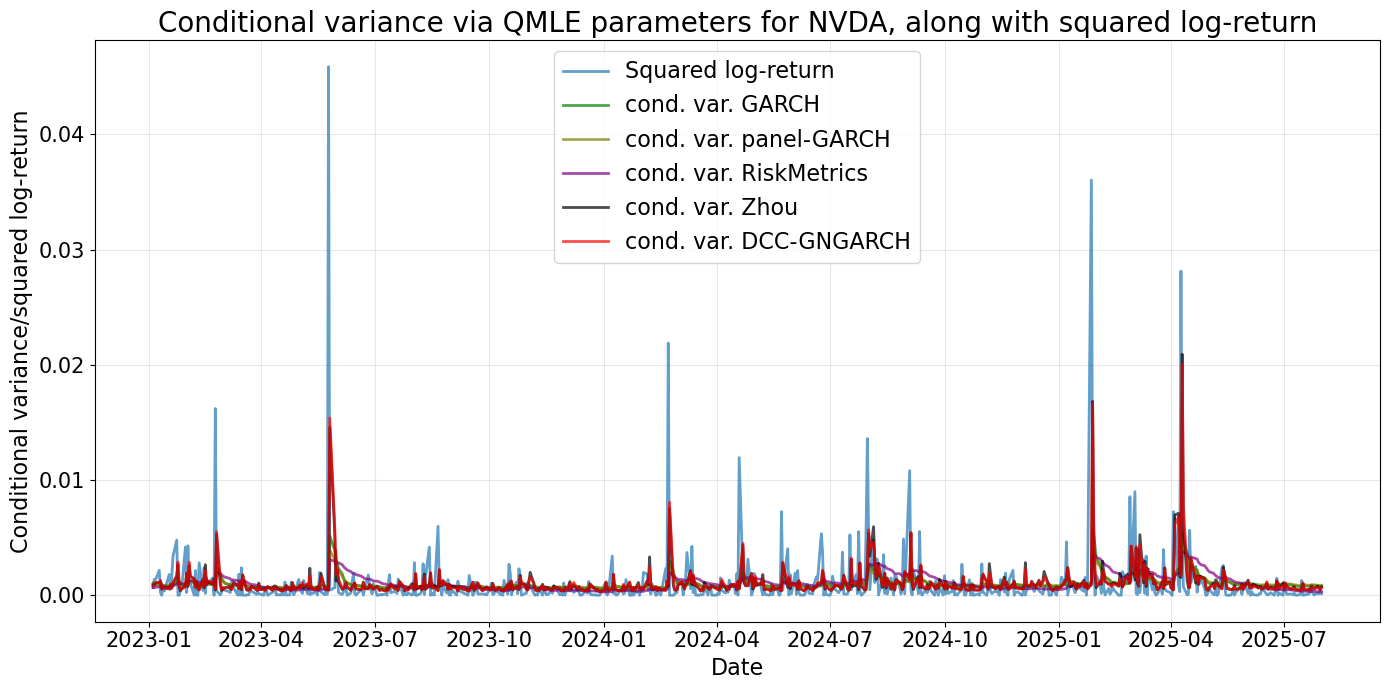

In [90]:
# cond_var_forecast_mse = dcc_gngarch_cond_var_forecast(W_total, A, params_mse, log_returns, log_returns)
cond_var_forecast_nll, Sigma_forecast_nll, R_forecast_nll = dcc_gngarch_cond_var_forecast(
    W=W_total,
    S=A,
    params=params_nll,
    train_data=log_returns_demean,
    val_data=log_returns_demean,
    window_size=126
)
# cond_var_forecast_mse_Zhou = network_GARCH_Zhou_cond_var_forecast(W_total, A, params_mse_Zhou, log_returns, log_returns)
cond_var_forecast_nll_Zhou = network_GARCH_Zhou_cond_var_forecast(W_total_unweighted, A, params_nll_Zhou, 
                                                                  log_returns_demean, log_returns_demean, window_size=126)
cond_var_forecast_nll_pgarch, Sigma_forecast_nll_pgarch, gamma_pgarch = panel_garch_cond_var_forecast(params_nll_pgarch, log_returns_demean, log_returns_demean, window_size=126)

cond_var_garch, cond_var_rm, cond_var_nll, cond_var_nll_Zhou = cond_var_comparison_inst(log_returns_demean, 'NVDA', 
                        cond_var_forecast_nll, cond_var_forecast_nll_Zhou, cond_var_forecast_nll_pgarch,
                        lam=0.94, params_garch=params_garch_all['NVDA'], rescale_window=252)

In [44]:
def cond_cov_inst(df, stock_name1, stock_name2, 
                  cond_cov_forecast_nll, rescale_window=252, rolling_window=60):
    """
    Compare model conditional covariance (co-volatility) forecasts with the empirical cross-product of two stocks as proxy.

    Args:
        df (pd.DataFrame): daily log-return series, index = dates, columns = stock names.
        stock_name1 (str): name of the first stock (column in df).
        stock_name2 (str): name of the second stock (column in df).
        cond_cov_forecast_nll (np.ndarray): model forecasts from QMLE/NLL fit, shape (T, d, d).
        rescale_window (int): window for dynamic rescaling, default 252.
        rolling_window (int): window for rolling median, default 252 for trading days in a year.
    """

    if not isinstance(stock_name1, str) or not isinstance(stock_name2, str):
        raise ValueError("Stock names must be strings.")
    if stock_name1 not in df.columns or stock_name2 not in df.columns:
        raise KeyError("One or both stock names are not columns of `df`.")

    # Extract indices for stocks
    stock_idx1 = df.columns.get_loc(stock_name1)
    stock_idx2 = df.columns.get_loc(stock_name2)

    # Define dates and total T
    dates = df.index
    T = len(dates)

    # Extract the (i,j) co-volatility series over time
    cond_cov_nll = pd.Series(cond_cov_forecast_nll[:, stock_idx1, stock_idx2], index=dates)

    # Empirical co-volatility proxy: cross-product of returns r_i * r_j (instantaneous)
    cross_prod = df[stock_name1] * df[stock_name2]

    # Dynamic rescale the model forecasts to align level with observed proxy (preserves dynamics)
    cond_cov_nll = dynamic_rescale(cond_cov_nll, cross_prod, rescale_window=rescale_window)

    s = pd.Series(cond_cov_nll, index=dates)  # convert back to a pd.Series, easy for taking the median and rolling median
    rolling_median = s.rolling(window=rolling_window).median()
    rolling_median = rolling_median.replace([np.inf, -np.inf], np.nan).bfill()  # replace nan with the first valid median

    # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    # axes[0].plot(dates, cross_prod, label=f'Cross product', alpha=0.7)
    # axes[0].axhline(0, color='k', linewidth=1.5, label='zero baseline')
    # axes[0].set_title(f'Cross log-return product between {stock_name1} and {stock_name2}', fontsize=20)
    # axes[0].set_xlabel('Date', fontsize=16)
    # axes[0].set_ylabel('Cross log-return product', fontsize=16)
    # axes[0].tick_params(axis='both', which='major', labelsize=15)
    # axes[0].legend(fontsize=16)
    # axes[0].grid(alpha=0.3)

    # axes[1].plot(dates, cond_cov_nll, label='cond. cov. GNGARCH', color='r', alpha=0.7)
    # axes[1].plot(rolling_median.index, rolling_median, color='k', linewidth=1.5, label=f'{rolling_window}-day rolling median')
    # axes[1].set_title(f'Conditional covariance via QMLE parameters between {stock_name1} and {stock_name2}', fontsize=20)
    # axes[1].set_xlabel('Date', fontsize=16)
    # axes[1].set_ylabel('Conditional covariance', fontsize=16)
    # axes[1].tick_params(axis='both', which='major', labelsize=15)
    # axes[1].legend(fontsize=16)
    # axes[1].grid(alpha=0.3)

    plt.figure(figsize=(14, 7))
    plt.plot(dates, cross_prod, label=f'Cross product', alpha=0.7)
    plt.axhline(0, color='k', linewidth=1.5, label='zero baseline')
    plt.plot(dates, cond_cov_nll, label='cond. cov. GNGARCH', color='r', alpha=0.7)
    plt.plot(rolling_median.index, rolling_median, color='y', linewidth=1.5, label=f'{rolling_window}-day rolling median')
    plt.title(f'Conditional covariance via QMLE parameters between {stock_name1} and {stock_name2}, along with cross products', fontsize=20)
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Conditional covariance/Cross log-return product', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(fontsize=16)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return cond_cov_nll, rolling_median

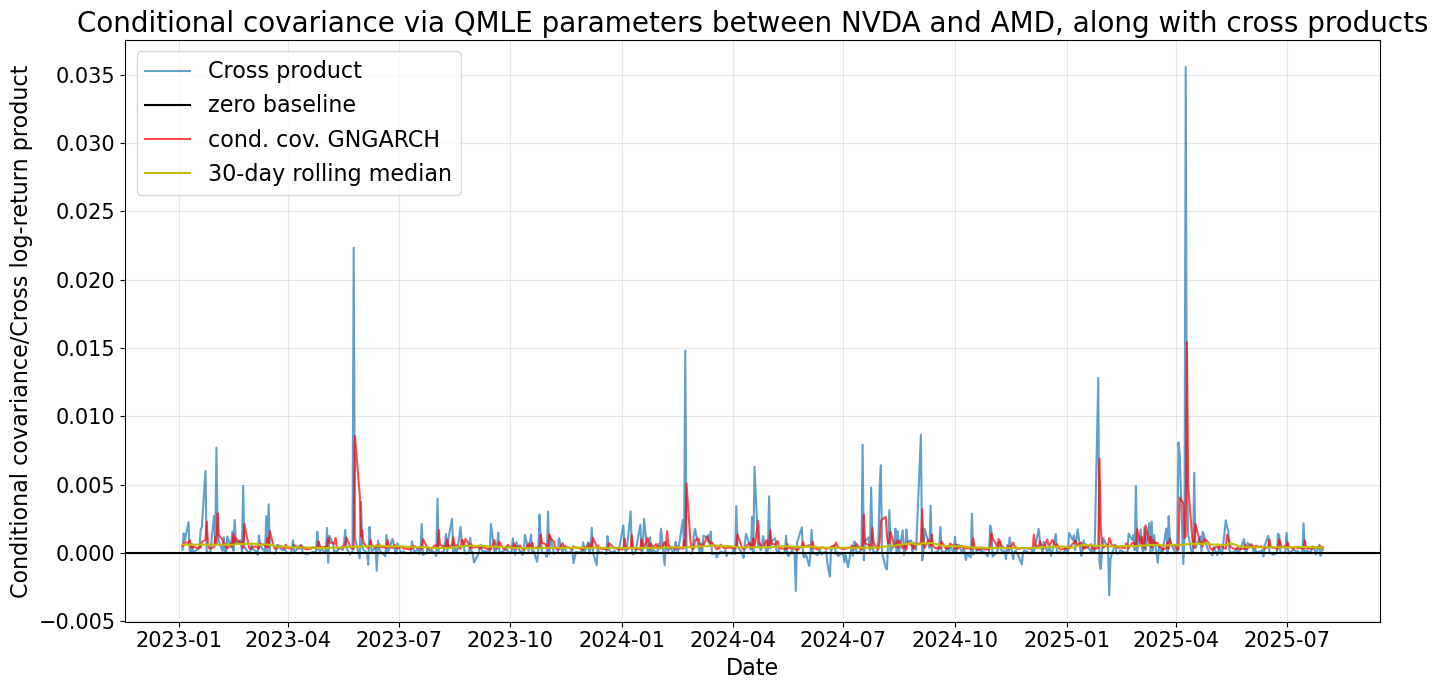

In [45]:
cond_cov_nll, rolling_median = cond_cov_inst(log_returns_demean, 'NVDA', 'AMD', cond_cov_forecast_nll=Sigma_forecast_nll,
                                             rescale_window=252, rolling_window=30)

# Quantitative forecast/predictive accuracy - DM test

Can the model achieve better estimation/forecast along with all stocks? This should be done on the test set.

#### Test set construction and qualitative analysis

In [46]:
# Fetch high-frequency (minute-ly) closing prices
val_data = yf.download(
    tickers=tickers,
    start='2025-08-02',
    end='2026-03-01',
    interval='1d',
    group_by='ticker'
)

# Create clean DataFrame
val_closing_prices = pd.DataFrame({
    t: val_data[t]['Close'] for t in tickers
}).dropna()

# Calculate the daily log returns (trade working days)
val_log_returns = np.log(val_closing_prices).diff().dropna()
val_log_returns_demean = val_log_returns - val_log_returns.mean()  # centering

[*********************100%***********************]  75 of 75 completed


Write the one-step forecast for different models.

In [47]:
def one_step_forecast(train_data, val_data, params, window_size=60):
    T_val, d = val_data.shape
    cond_var_forecast_arr = np.zeros((T_val, d))
    cond_cov_forecast_arr = np.zeros((T_val, d, d))
    
    # Initialise with training data
    current_data = train_data.copy()
    
    for i in range(T_val):
        # Get next validation observation
        next_obs = val_data.iloc[[i]]  # keep as DataFrame
        
        # Make 1-step forecast using current data       
        cond_var_forecast, Sigma_forecast, _ = dcc_gngarch_cond_var_forecast(
            W=W_total,
            S=A,
            params=params,
            train_data=current_data,
            val_data=next_obs,
            window_size=window_size
        )

        # Store forecasts
        cond_var_forecast_arr[i] = cond_var_forecast
        cond_cov_forecast_arr[i] = Sigma_forecast
        
        # Update data maintaining window size
        current_data = pd.concat([current_data, next_obs])
        if len(current_data) > window_size:
            current_data = current_data.iloc[-window_size:]
    
    return cond_var_forecast_arr, cond_cov_forecast_arr

In [48]:
def one_step_forecast_Zhou(train_data, val_data, params, window_size=60):
    T_val, d = val_data.shape
    cond_var_forecast_arr = np.zeros((T_val, d))
    
    # Initialise with training data
    current_data = train_data.copy()
    
    for i in range(T_val):
        # Get next validation observation
        next_obs = val_data.iloc[[i]]  # keep as DataFrame
        
        # Make 1-step forecast using current data
        cond_var_forecast = network_GARCH_Zhou_cond_var_forecast(
            W_total_unweighted, A, params, current_data, next_obs, window_size
        )
        
        # Store forecasts
        cond_var_forecast_arr[i] = cond_var_forecast
        
        # Update data maintaining window size
        current_data = pd.concat([current_data, next_obs])
        if len(current_data) > window_size:
            current_data = current_data.iloc[-window_size:]
    
    return cond_var_forecast_arr

In [49]:
def garch_one_step_from_window(train_series, params_garch):
    """
    Produce one-step-ahead variance forecast for a single stock
    from a rolling window using fitted GARCH(1,1) parameters.

    Parameters
    ----------
    train_series : pd.Series or np.ndarray
        Historical return series up to forecast origin
    params_garch : pd.Series or dict
        Must contain omega, alpha[1], beta[1]
        (and optionally mu if mean != Zero)

    Returns
    -------
    h_next : float
        One-step-ahead conditional variance forecast
    """
    r = np.asarray(train_series, dtype=float)

    omega = params_garch['omega']
    alpha = params_garch['alpha[1]']
    beta = params_garch['beta[1]']

    # Zero-mean case
    if 'mu' in params_garch:
        mu = params_garch['mu']
        eps = r - mu
    else:
        eps = r

    # initialise with sample variance of residuals
    h_prev = np.var(eps, ddof=1)

    # recurse through the window
    for t in range(1, len(eps)):
        h_prev = omega + alpha * (eps[t - 1] ** 2) + beta * h_prev

    # one-step-ahead forecast
    h_next = omega + alpha * (eps[-1] ** 2) + beta * h_prev
    return h_next


def one_step_forecast_garch(train_data, val_data, params_garch_all, window_size=60):
    """
    Rolling one-step-ahead variance forecast for all stocks using
    fitted univariate GARCH(1,1) parameters.

    Parameters
    ----------
    train_data : pd.DataFrame
        Training return data
    val_data : pd.DataFrame
        Validation/test return data
    params_garch_all : dict
        Dictionary keyed by stock name, each value is fitted parameter vector
    window_size : int
        Rolling window size

    Returns
    -------
    cond_var_forecast_arr : np.ndarray
        Shape (T_val, d), one-step-ahead variance forecasts
    """
    T_val, d = val_data.shape
    cond_var_forecast_arr = np.zeros((T_val, d))

    current_data = train_data.copy()

    for i in range(T_val):
        next_obs = val_data.iloc[[i]]  # one-row DataFrame

        for j, stock_name in enumerate(current_data.columns):
            train_series = current_data[stock_name]
            params_garch = params_garch_all[stock_name]

            h_next = garch_one_step_from_window(train_series, params_garch)
            cond_var_forecast_arr[i, j] = h_next

        # update rolling window with realised next observation
        current_data = pd.concat([current_data, next_obs])
        if len(current_data) > window_size:
            current_data = current_data.iloc[-window_size:]

    return cond_var_forecast_arr

In [50]:
def riskmetrics_one_step_from_window(train_series, lam=0.94):
    """
    Produce one-step-ahead variance forecast for a single stock
    from a rolling window using RiskMetrics.

    Parameters
    ----------
    train_series : pd.Series or np.ndarray
        Historical demeaned return series up to forecast origin.
    lam : float
        Decay parameter, default 0.94 for daily data.

    Returns
    -------
    h_next : float
        One-step-ahead conditional variance forecast.
    """
    r = np.asarray(train_series, dtype=float)

    # Initialise with sample variance
    h_prev = np.var(r, ddof=1)

    # Recurse through the window
    for t in range(1, len(r)):
        h_prev = lam * h_prev + (1.0 - lam) * (r[t - 1] ** 2)

    # One-step-ahead forecast
    h_next = lam * h_prev + (1.0 - lam) * (r[-1] ** 2)
    return h_next


def one_step_forecast_riskmetrics(train_data, val_data, lam=0.94, window_size=60):
    """
    Rolling one-step-ahead variance forecast for all stocks using RiskMetrics.

    Parameters
    ----------
    train_data : pd.DataFrame
        Training return data.
    val_data : pd.DataFrame
        Validation/test return data.
    lam : float
        Decay parameter, default 0.94.
    window_size : int
        Rolling window size.

    Returns
    -------
    cond_var_forecast_arr : np.ndarray
        Shape (T_val, d), one-step-ahead variance forecasts.
    """
    T_val, d = val_data.shape
    cond_var_forecast_arr = np.zeros((T_val, d))

    current_data = train_data.copy()

    for i in range(T_val):
        next_obs = val_data.iloc[[i]]  # one-row DataFrame

        for j, stock_name in enumerate(current_data.columns):
            train_series = current_data[stock_name]
            h_next = riskmetrics_one_step_from_window(train_series, lam=lam)
            cond_var_forecast_arr[i, j] = h_next

        # Update rolling window with realised next observation
        current_data = pd.concat([current_data, next_obs])
        if len(current_data) > window_size:
            current_data = current_data.iloc[-window_size:]

    return cond_var_forecast_arr

In [91]:
def panel_garch_one_step_from_window(train_window, params_panel, gamma=None):
    """
    Produce one-step-ahead variance forecasts for all stocks from a rolling window
    under variance-targeted panel GARCH(1,1).

    Model:
        h_{i,t} = gamma_i (1 - alpha - beta) + alpha * x_{i,t-1}^2 + beta * h_{i,t-1}

    Parameters
    ----------
    train_window : pd.DataFrame or np.ndarray
        Historical demeaned return data up to forecast origin, shape (T, d)
    params_panel : dict
        Must contain:
            alpha, beta
    gamma : np.ndarray or pd.Series or None
        Stock-specific long-run variances gamma_i.
        If None, estimate from the current window by method of moments:
            gamma_i = mean(x_i^2)

    Returns
    -------
    h_next : np.ndarray
        One-step-ahead conditional variance forecast, shape (d,)
    """
    X = np.asarray(train_window, dtype=float)
    alpha = params_panel['alpha']
    beta = params_panel['beta']

    if X.ndim != 2:
        raise ValueError("train_window must be 2D with shape (T, d).")

    # Variance targeting level gamma_i
    if gamma is None:
        gamma = np.mean(X ** 2, axis=0)  # VTE
    else:
        gamma = np.asarray(gamma, dtype=float)

    gamma = np.clip(gamma, 1e-10, None)

    # Initial variance state
    h_prev = gamma.copy()

    # Recurse through the window
    for t in range(1, X.shape[0]):
        h_prev = gamma * (1.0 - alpha - beta) + alpha * (X[t - 1] ** 2) + beta * h_prev
        h_prev = np.clip(h_prev, 1e-10, None)

    # One-step-ahead forecast
    h_next = gamma * (1.0 - alpha - beta) + alpha * (X[-1] ** 2) + beta * h_prev
    h_next = np.clip(h_next, 1e-10, None)

    return h_next


def one_step_forecast_panel_garch(train_data, val_data, params_panel, window_size=60, gamma_mode='fixed'):
    """
    Rolling one-step-ahead variance forecast for all stocks using
    fitted panel GARCH(1,1) parameters.

    Parameters
    ----------
    train_data : pd.DataFrame
        Training demeaned return data
    val_data : pd.DataFrame
        Validation/test demeaned return data
    params_panel : dict
        Dictionary with keys:
            alpha, beta
    window_size : int
        Rolling window size
    gamma_mode : str
        'fixed'   : estimate gamma once from the initial training data and keep it fixed
        'rolling' : re-estimate gamma from the current rolling window each step

    Returns
    -------
    cond_var_forecast_arr : np.ndarray
        Shape (T_val, d), one-step-ahead variance forecasts
    """
    T_val, d = val_data.shape
    cond_var_forecast_arr = np.zeros((T_val, d))

    current_data = train_data.copy()

    # Fixed gamma from initial training sample
    if gamma_mode == 'fixed':
        gamma_fixed = np.mean(train_data.to_numpy(dtype=float) ** 2, axis=0)
        gamma_fixed = np.clip(gamma_fixed, 1e-10, None)
    elif gamma_mode == 'rolling':
        gamma_fixed = None
    else:
        raise ValueError("gamma_mode must be either 'fixed' or 'rolling'.")

    for i in range(T_val):
        next_obs = val_data.iloc[[i]]  # one-row DataFrame

        if gamma_mode == 'fixed':
            gamma_use = gamma_fixed
        else:
            gamma_use = np.mean(current_data.to_numpy(dtype=float) ** 2, axis=0)
            gamma_use = np.clip(gamma_use, 1e-10, None)

        h_next = panel_garch_one_step_from_window(
            train_window=current_data,
            params_panel=params_panel,
            gamma=gamma_use
        )
        cond_var_forecast_arr[i, :] = h_next

        # update rolling window with realised next observation
        current_data = pd.concat([current_data, next_obs])
        if len(current_data) > window_size:
            current_data = current_data.iloc[-window_size:]

    return cond_var_forecast_arr

---

In [51]:
def dynamic_rescale_test_all_stocks(train_returns, test_returns, test_forecast, rescale_window=252):
    """
    Dynamically rescale test-period forecasts for all stocks using
    rolling information from the combined train+test history.

    Parameters
    ----------
    train_returns : pd.DataFrame
        Training demeaned returns, shape (T_train, d).
    test_returns : pd.DataFrame
        Test demeaned returns, shape (T_test, d).
    test_forecast : np.ndarray or pd.DataFrame
        Raw test-period conditional variance forecasts, shape (T_test, d).
    rescale_window : int
        Rolling rescale window.

    Returns
    -------
    scaled_test_forecast_df : pd.DataFrame
        Rescaled test-period forecasts, shape (T_test, d).
    """
    if not isinstance(train_returns, pd.DataFrame) or not isinstance(test_returns, pd.DataFrame):
        raise ValueError("train_returns and test_returns must be pandas DataFrames.")

    if list(train_returns.columns) != list(test_returns.columns):
        raise ValueError("train_returns and test_returns must have the same columns.")

    T_test, d = test_returns.shape

    if isinstance(test_forecast, np.ndarray):
        if test_forecast.shape != (T_test, d):
            raise ValueError(f"test_forecast must have shape {(T_test, d)}")
        test_forecast_df = pd.DataFrame(test_forecast, index=test_returns.index, columns=test_returns.columns)
    else:
        test_forecast_df = test_forecast.copy()

    # Combine returns history
    full_returns = pd.concat([train_returns, test_returns], axis=0)
    full_squared = full_returns ** 2

    # For forecast history, only test-period forecasts are available here,
    # so prepend NaNs over training dates
    train_nan = pd.DataFrame(
        np.nan,
        index=train_returns.index,
        columns=train_returns.columns
    )
    full_forecast = pd.concat([train_nan, test_forecast_df], axis=0)

    rolling_realised_var = full_squared.rolling(window=rescale_window, min_periods=1).mean()
    rolling_forecast_var = full_forecast.rolling(window=rescale_window, min_periods=1).mean()

    ratio = rolling_realised_var / rolling_forecast_var
    ratio = ratio.replace([np.inf, -np.inf], np.nan).bfill()

    scaled_full_forecast = full_forecast * ratio
    scaled_test_forecast_df = scaled_full_forecast.loc[test_returns.index]

    # Convert into numpy
    scaled_test_forecast = scaled_test_forecast_df.values

    return scaled_test_forecast

In [92]:
cond_var_forecast_dcc_gngarch_arr, cond_cov_forecast_dcc_gngarch_arr = one_step_forecast(log_returns_demean, val_log_returns_demean, params_nll, window_size=60)
cond_var_forecast_Zhou_arr = one_step_forecast_Zhou(log_returns_demean, val_log_returns_demean, params_nll_Zhou, window_size=60)
cond_var_forecast_garch_arr = one_step_forecast_garch(log_returns_demean, val_log_returns_demean, params_garch_all, window_size=60)
cond_var_forecast_riskmetrics_arr = one_step_forecast_riskmetrics(log_returns_demean, val_log_returns_demean, lam=0.94, window_size=60)
cond_var_forecast_pgarch_arr = one_step_forecast_panel_garch(log_returns_demean, val_log_returns_demean, params_nll_pgarch, window_size=60, gamma_mode='fixed')

# Rescaling is needed...
cond_var_forecast_dcc_gngarch_rescaled = dynamic_rescale_test_all_stocks(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_var_forecast_dcc_gngarch_arr,
    rescale_window=252
)

cond_var_forecast_Zhou_rescaled = dynamic_rescale_test_all_stocks(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_var_forecast_Zhou_arr,
    rescale_window=252
)

cond_var_forecast_garch_rescaled = dynamic_rescale_test_all_stocks(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_var_forecast_garch_arr,
    rescale_window=252
)

cond_var_forecast_riskmetrics_rescaled = dynamic_rescale_test_all_stocks(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_var_forecast_riskmetrics_arr,
    rescale_window=252
)

cond_var_forecast_pgarch_rescaled = dynamic_rescale_test_all_stocks(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_var_forecast_pgarch_arr,
    rescale_window=252
)

We do the realised conditional variance with a rolling window of 30-day.

In [98]:
# 1. Define the rolling window size
window = 60 

# 2. Get the noisy proxy (daily squared returns)
# Assuming val_log_returns_demean is already a pandas DataFrame
actual_sq_returns = val_log_returns_demean ** 2

# 3. Compute the rolling proxy
# We use .mean() to keep the scale as "average daily variance". 
# .dropna() removes the first 29 days which will be NaN due to the rolling window.
rolling_actual_var = actual_sq_returns.rolling(window=window).mean().dropna()

# 4. Convert forecast arrays to DataFrames (preserving column names if possible)
columns = val_log_returns_demean.columns
df_dcc = pd.DataFrame(cond_var_forecast_dcc_gngarch_rescaled, columns=columns, index=val_log_returns_demean.index)
df_Zhou = pd.DataFrame(cond_var_forecast_Zhou_rescaled, columns=columns, index=val_log_returns_demean.index)
df_garch = pd.DataFrame(cond_var_forecast_garch_rescaled, columns=columns, index=val_log_returns_demean.index)
df_rm = pd.DataFrame(cond_var_forecast_riskmetrics_rescaled, columns=columns, index=val_log_returns_demean.index)
df_pgarch = pd.DataFrame(cond_var_forecast_pgarch_rescaled, columns=columns, index=val_log_returns_demean.index)

# 5. Compute the rolling forecasts
rolling_forecast_dcc = df_dcc.rolling(window=window).mean().dropna()
rolling_forecast_Zhou = df_Zhou.rolling(window=window).mean().dropna()
rolling_forecast_garch = df_garch.rolling(window=window).mean().dropna()
rolling_forecast_rm = df_rm.rolling(window=window).mean().dropna()
rolling_forecast_pgarch = df_pgarch.rolling(window=window).mean().dropna()

# Verify the new shapes (should be 143 - 30 + 1 = 114 days, 75 stocks)
print(f'Original shape: {actual_sq_returns.shape}')
print(f'Rolling shape:  {rolling_actual_var.shape}')

Original shape: (143, 75)
Rolling shape:  (84, 75)


In [68]:
# We also need rescaling on the covariance based on cross product

def dynamic_rescale_test_pair_cov(train_returns, test_returns, test_forecast,
                                  stock_name1, stock_name2, rescale_window=252):
    """
    Dynamically rescale test-period conditional covariance forecasts for one stock pair
    using rolling information from the combined train+test history.

    Parameters
    ----------
    train_returns : pd.DataFrame
        Training demeaned returns, shape (T_train, d).
    test_returns : pd.DataFrame
        Test demeaned returns, shape (T_test, d).
    test_forecast : np.ndarray, pd.Series, or pd.DataFrame
        Raw test-period conditional covariance forecast for the pair, shape (T_test,).
    stock_name1, stock_name2 : str
        Names of the two stocks used to form the cross-product proxy.
    rescale_window : int
        Rolling rescale window.

    Returns
    -------
    scaled_test_forecast : np.ndarray
        Rescaled test-period conditional covariance forecast, shape (T_test,).
    """
    if not isinstance(train_returns, pd.DataFrame) or not isinstance(test_returns, pd.DataFrame):
        raise ValueError("train_returns and test_returns must be pandas DataFrames.")

    if list(train_returns.columns) != list(test_returns.columns):
        raise ValueError("train_returns and test_returns must have the same columns.")

    if stock_name1 not in train_returns.columns or stock_name2 not in train_returns.columns:
        raise KeyError("One or both stock names are not in the return DataFrames.")

    T_test = len(test_returns)

    # Convert forecast to Series
    if isinstance(test_forecast, np.ndarray):
        if test_forecast.ndim != 1 or len(test_forecast) != T_test:
            raise ValueError(f"test_forecast must have shape ({T_test},)")
        test_forecast_ser = pd.Series(test_forecast, index=test_returns.index)
    elif isinstance(test_forecast, pd.Series):
        test_forecast_ser = test_forecast.copy()
    else:
        raise ValueError("test_forecast must be a 1D numpy array or pd.Series.")

    # Combine return history
    full_returns = pd.concat([train_returns, test_returns], axis=0)

    # Cross-product proxy
    full_cross = full_returns[stock_name1] * full_returns[stock_name2]

    # Forecast history: prepend NaNs over training dates
    train_nan = pd.Series(np.nan, index=train_returns.index)
    full_forecast = pd.concat([train_nan, test_forecast_ser], axis=0)

    rolling_realised_cov = full_cross.rolling(window=rescale_window, min_periods=1).mean()
    rolling_forecast_cov = full_forecast.rolling(window=rescale_window, min_periods=1).mean()

    ratio = rolling_realised_cov / rolling_forecast_cov
    ratio = ratio.replace([np.inf, -np.inf], np.nan).bfill()

    scaled_full_forecast = full_forecast * ratio
    scaled_test_forecast = scaled_full_forecast.loc[test_returns.index].values

    return scaled_test_forecast

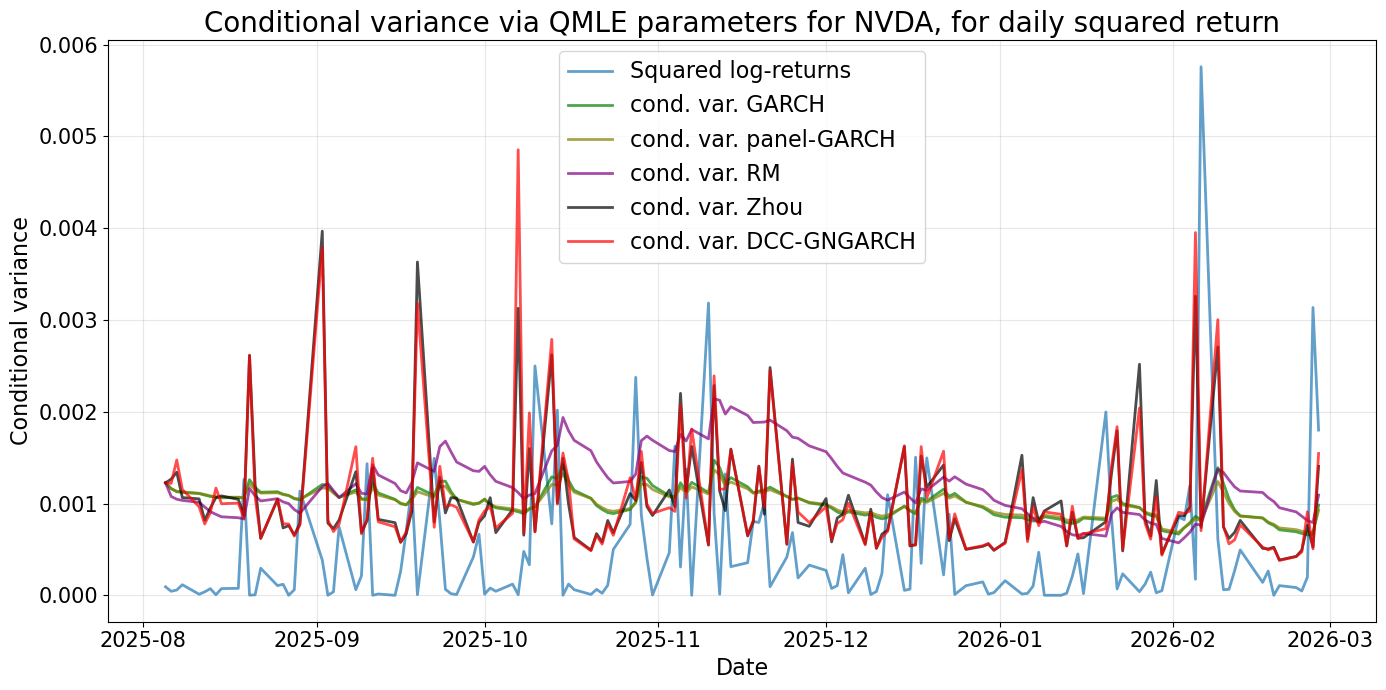

In [99]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
dates = val_log_returns_demean.index
stock_name = 'NVDA'
stock_idx = val_log_returns_demean.columns.get_loc(stock_name)

plt.figure(figsize=(14, 7))
plt.plot(dates, val_log_returns_demean[stock_name] ** 2, label=f'Squared log-returns', lw=2, alpha=0.7)
plt.plot(dates, cond_var_forecast_garch_rescaled[:, stock_idx], label='cond. var. GARCH', color='g', lw=2, alpha=0.7)
plt.plot(dates, cond_var_forecast_pgarch_rescaled[:, stock_idx], label='cond. var. panel-GARCH', color='olive', lw=2, alpha=0.7)
plt.plot(dates, cond_var_forecast_riskmetrics_rescaled[:, stock_idx], label='cond. var. RM', color='purple', lw=2, alpha=0.7)
plt.plot(dates, cond_var_forecast_Zhou_rescaled[:, stock_idx], label='cond. var. Zhou', color='k', lw=2, alpha=0.7)
plt.plot(dates, cond_var_forecast_dcc_gngarch_rescaled[:, stock_idx], label='cond. var. DCC-GNGARCH', color='r', lw=2, alpha=0.7)
plt.title(f'Conditional variance via QMLE parameters for {stock_name}, for daily squared return', fontsize=20)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Conditional variance', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(fontsize=16)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

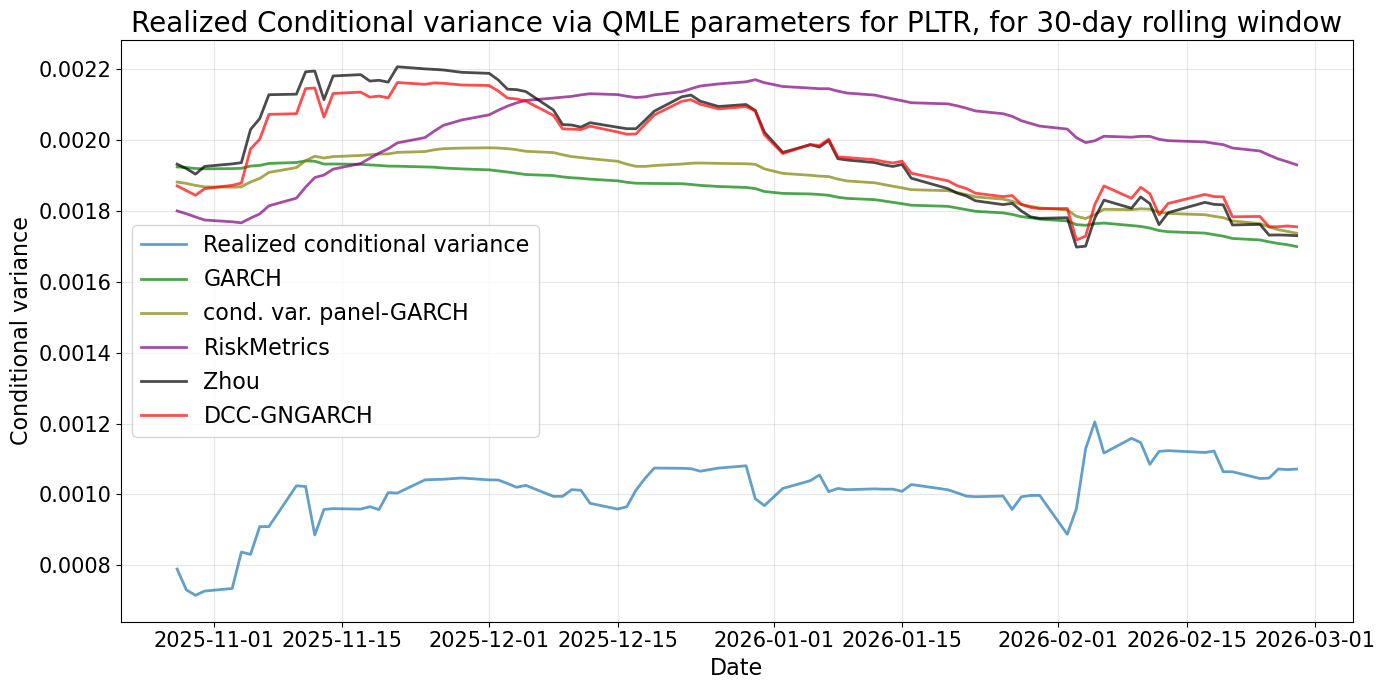

In [100]:
dates = rolling_actual_var.index
stock_name = 'PLTR'

plt.figure(figsize=(14, 7))
plt.plot(dates, rolling_actual_var[stock_name], label=f'Realized conditional variance', lw=2, alpha=0.7)
plt.plot(dates, rolling_forecast_garch[stock_name], color='g', label='GARCH', lw=2, alpha=0.7)
plt.plot(dates, rolling_forecast_pgarch[stock_name], color='olive', label='cond. var. panel-GARCH', lw=2, alpha=0.7)
plt.plot(dates, rolling_forecast_rm[stock_name], color = 'purple', label='RiskMetrics', lw=2, alpha=0.7)
plt.plot(dates, rolling_forecast_Zhou[stock_name], color='k', label='Zhou', lw=2, alpha=0.7)
plt.plot(dates, rolling_forecast_dcc[stock_name], color='r', label='DCC-GNGARCH', lw=2, alpha=0.7)
plt.title(f'Realized Conditional variance via QMLE parameters for {stock_name}, for 30-day rolling window', fontsize=20)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Conditional variance', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.legend(fontsize=16)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

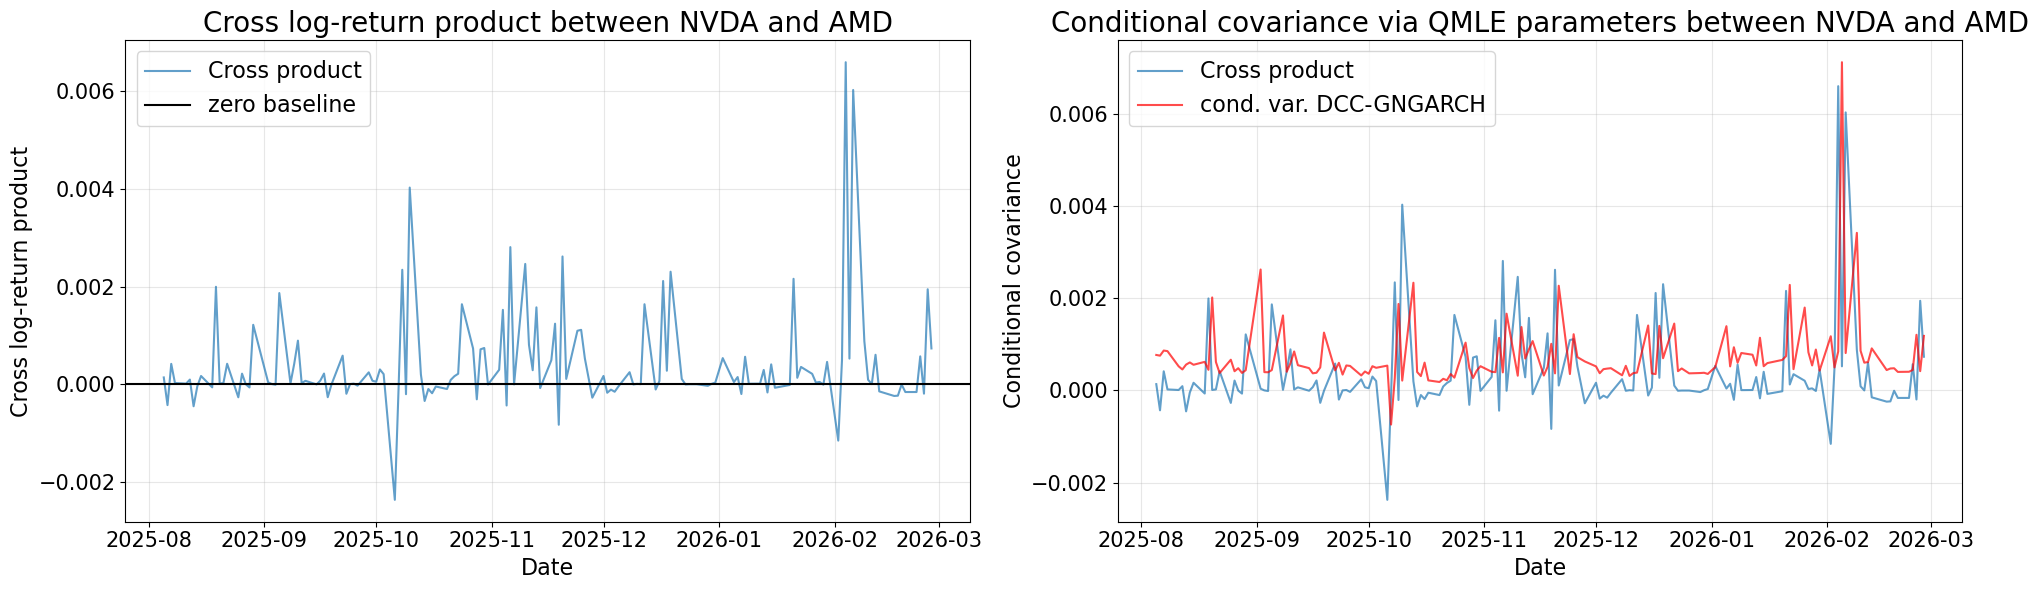

In [71]:
dates = val_log_returns_demean.index
stock_name1, stock_name2 = 'NVDA', 'AMD' 
stock_idx1 = val_log_returns_demean.columns.get_loc(stock_name1)
stock_idx2 = val_log_returns_demean.columns.get_loc(stock_name2)
cross_prod = val_log_returns['NVDA'] * val_log_returns['AMD']
cond_cov_forecast_dcc_gngarch_rescaled = dynamic_rescale_test_pair_cov(
    train_returns=log_returns_demean,
    test_returns=val_log_returns_demean,
    test_forecast=cond_cov_forecast_dcc_gngarch_arr[:, stock_idx1, stock_idx2],
    stock_name1 = stock_name1,
    stock_name2 = stock_name2,
    rescale_window=252
)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
axes[0].plot(dates, cross_prod, label=f'Cross product', alpha=0.7)
axes[0].axhline(0, color='k', linewidth=1.5, label='zero baseline')
axes[0].set_title(f'Cross log-return product between {stock_name1} and {stock_name2}', fontsize=20)
axes[0].set_xlabel('Date', fontsize=16)
axes[0].set_ylabel('Cross log-return product', fontsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=15)
axes[0].legend(fontsize=16)
axes[0].grid(alpha=0.3)

    # axes[1].plot(dates, cond_cov_nll_val, label='cond. cov. GNGARCH', color='r', alpha=0.7)
    # axes[1].plot(rolling_median.index[rolling_window:], rolling_median[rolling_window:], color='k', linewidth=1.5, label=f'{rolling_window}-day rolling median')
    # #axes[1].plot(rolling_median.index, rolling_median, color='k', linewidth=1.5, label=f'{rolling_window}-day rolling median')
    # axes[1].set_title(f'Conditional covariance via QMLE parameters between {stock_name1} and {stock_name2}', fontsize=20)
    # axes[1].set_xlabel('Date', fontsize=16)
    # axes[1].set_ylabel('Conditional covariance', fontsize=16)
    # axes[1].tick_params(axis='both', which='major', labelsize=15)
    # axes[1].legend(fontsize=16)
    # axes[1].grid(alpha=0.3)


axes[1].plot(dates, cross_prod, label=f'Cross product', alpha=0.7)
axes[1].plot(dates, cond_cov_forecast_dcc_gngarch_rescaled, label='cond. var. DCC-GNGARCH', color='r', alpha=0.7)
axes[1].set_title(f'Conditional covariance via QMLE parameters between {stock_name1} and {stock_name2}', fontsize=20)
axes[1].set_xlabel('Date', fontsize=16)
axes[1].set_ylabel('Conditional covariance', fontsize=16)
axes[1].tick_params(axis='both', which='major', labelsize=15)
axes[1].legend(fontsize=16)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# DM test

In [72]:
def diebold_mariano_test(loss1, loss2, nw_lags=None, horizon=1, hln_adjust=False):
    """
    Diebold-Mariano test for equal predictive accuracy
    using HAC/Newey-West long-run variance.

    Parameters
    ----------
    loss1, loss2 : array-like
        Same-length loss series for two competing models.
    nw_lags : int, optional
        Newey-West truncation lag. If None, defaults to round(T^(1/3)).
    horizon : int
        Forecast horizon. Default is 1.
    hln_adjust : bool
        Whether to apply the Harvey-Leybourne-Newbold small-sample adjustment.

    Returns
    -------
    dm_stat : float
    p_value : float
    mean_diff : float
        Mean(loss1 - loss2). Negative means model 1 is better.
    """
    loss1 = np.asarray(loss1, dtype=float)
    loss2 = np.asarray(loss2, dtype=float)

    if loss1.shape != loss2.shape:
        raise ValueError("loss1 and loss2 must have the same shape.")

    d = loss1 - loss2
    d = d[np.isfinite(d)]

    T = len(d)
    if T < 5:
        raise ValueError("Not enough observations for DM test.")

    d_bar = np.mean(d)

    if nw_lags is None:
        nw_lags = int(np.round(T ** (1/3)))

    # Long-run variance estimate
    gamma_0 = np.sum((d - d_bar) ** 2) / T
    lrv = gamma_0

    for k in range(1, nw_lags + 1):
        gamma_k = np.sum((d[:T-k] - d_bar) * (d[k:] - d_bar)) / T
        weight = 1.0 - k / (nw_lags + 1.0)   # Bartlett kernel
        lrv += 2.0 * weight * gamma_k

    if lrv <= 0:
        return 0.0, 1.0, d_bar

    dm_stat = d_bar / np.sqrt(lrv / T)

    # Optional HLN small-sample adjustment
    if hln_adjust:
        correction = np.sqrt((T + 1 - 2*horizon + horizon*(horizon - 1)/T) / T)
        dm_stat *= correction

    p_value = 2.0 * (1.0 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value, d_bar

In [73]:
def patton_robust_loss(actual_proxy, forecast_var, b, eps=1e-8):
    """
    Computes Patton's (2011) family of robust loss functions.
    
    Parameters
    ----------
    actual_proxy : array-like
        The realized variance proxy (e.g., squared returns), \hat{\sigma}^2.
    forecast_var : array-like
        The conditional variance forecast, h.
    b : float
        The shape parameter. 
        b = 0 is MSE-like (symmetric). 
        b = -2 is QLIKE-like (asymmetric, heavily penalizes under-prediction).
    eps : float
        Small number to prevent division by zero or log(0).
        
    Returns
    -------
    loss : numpy.ndarray
        The computed loss series.
    """
    y = np.asarray(actual_proxy, dtype=float)
    h = np.asarray(forecast_var, dtype=float)
    
    # Clip h to avoid division by zero or log(0) in volatile financial data
    h = np.clip(h, eps, None)
    
    # Clip y for log calculations if b == -1 or b == -2
    y_safe = np.clip(y, eps, None)

    if b == -1:
        # L = h - y + y * log(y/h)
        loss = h - y + y * np.log(y_safe / h)
        
    elif b == -2:
        # L = (y/h) - log(y/h) - 1
        loss = (y / h) - np.log(y_safe / h) - 1
        
    else:
        # L = (1 / ((b+1)*(b+2))) * (y^(2b+4) - h^(b+2)) - (1 / (b+1)) * h^(b+1) * (y - h)
        term1 = 1 / ((b + 1) * (b + 2))
        term2 = (y ** (2 * b + 4)) - (h ** (b + 2))
        term3 = 1 / (b + 1)
        term4 = (h ** (b + 1)) * (y - h)
        
        loss = term1 * term2 - term3 * term4
        
    return loss

In [74]:
def dm_test_over_stocks_multi(df, forecast1, other_forecasts, b_vals):
    """
    Compute stock-by-stock Diebold-Mariano tests comparing one fixed forecast1
    against multiple alternative forecast matrices over all stocks in df,
    across a range of b-values for Patton's robust loss function.

    Negative DM statistic means forecast1 is better.

    Uses one-sided 5% significance:
        DM <= -1.645  => significant evidence that forecast1 is better.

    Adds summary rows for:
    - negative count / proportion
    - negative significant count / proportion at 5% one-sided
    """

    # --- HELPER FUNCTION: Add significance stars: LaTeX math-mode ---
    def significance_level(stat):
        if stat <= -1.645:   # one-sided significance level 0.05
            return f"${stat:.2f}^{{*}}$"
        else:
            return f"${stat:.2f}$"
    # -----------------------------------------------

    if not isinstance(df, pd.DataFrame):
        raise ValueError("df must be a pandas DataFrame.")

    forecast1 = np.asarray(forecast1, dtype=float)
    T, d = df.shape
    n_stocks = d

    if forecast1.shape != (T, d):
        raise ValueError(f"forecast1 must have shape {(T, d)}, got {forecast1.shape}")

    for name, fc in other_forecasts.items():
        fc = np.asarray(fc, dtype=float)
        if fc.shape != (T, d):
            raise ValueError(f"Forecast '{name}' must have shape {(T, d)}, got {fc.shape}")

    results = []
    numeric_results = []

    for stock_idx, stock_name in enumerate(df.columns):
        proxy = df[stock_name].to_numpy(dtype=float) ** 2
        stock_results = {'stock': stock_name}
        stock_numeric = {'stock': stock_name}

        for model_name, forecast_alt in other_forecasts.items():
            forecast_alt = np.asarray(forecast_alt, dtype=float)

            for b in b_vals:
                loss1 = patton_robust_loss(proxy, forecast1[:, stock_idx], b=b)
                loss2 = patton_robust_loss(proxy, forecast_alt[:, stock_idx], b=b)

                dm_stat, _, _ = diebold_mariano_test(loss1, loss2)

                col_name = f'DM_{model_name} (b={b})'
                stock_results[col_name] = significance_level(dm_stat)
                stock_numeric[col_name] = dm_stat

        results.append(stock_results)
        numeric_results.append(stock_numeric)

    results_df = pd.DataFrame(results)
    numeric_df = pd.DataFrame(numeric_results)

    # Build count row: number of negative DM stats
    count_row = {'stock': 'Negative count'}
    for col in numeric_df.columns:
        if col != 'stock':
            count_row[col] = int((numeric_df[col] < 0).sum())

    # Proportion row
    proportion_row = {'stock': 'Negative proportion'}
    for col in numeric_df.columns:
        if col != 'stock':
            proportion_row[col] = f'{count_row[col] / n_stocks:.2f}'

    # Build one-sided 5% significant negative count row
    neg_sig_5_row = {'stock': 'Neg. sig. count (5%)'}
    for col in numeric_df.columns:
        if col != 'stock':
            neg_sig_5_row[col] = int((numeric_df[col] <= -1.645).sum())

    # Proportion row for one-sided 5% significant negatives
    neg_sig_5_prop_row = {'stock': 'Neg. sig. proportion (5%)'}
    for col in numeric_df.columns:
        if col != 'stock':
            neg_sig_5_prop_row[col] = f'{neg_sig_5_row[col] / n_stocks:.2f}'

    results_df = pd.concat(
        [
            results_df,
            pd.DataFrame([count_row]),
            pd.DataFrame([proportion_row]),
            pd.DataFrame([neg_sig_5_row]),
            pd.DataFrame([neg_sig_5_prop_row]),
        ],
        ignore_index=True
    )

    return results_df

In [101]:
# TEST OUT-OF-SAMPLE predictive accuracy
other_forecasts = {
    'GARCH': rolling_forecast_garch,
    'panel-GARCH': rolling_forecast_pgarch,
    'RiskMetrics': rolling_forecast_rm,
    'Zhou': rolling_forecast_Zhou
}

dm_results_rolling = dm_test_over_stocks_multi(
    df=np.sqrt(rolling_actual_var),
    forecast1=rolling_forecast_dcc,
    other_forecasts=other_forecasts,
    b_vals=[-2, 0]
)

dm_results_rolling

latex_table = dm_results_rolling.to_latex(index=False, escape=False,
                                  caption="Diebold-Mariano Test Results", label="tab:dm_test")

# Print the result or write it to a .tex file
print(latex_table)
dm_results_rolling

\begin{table}
\centering
\caption{Diebold-Mariano Test Results}
\label{tab:dm_test}
\begin{tabular}{lllllllll}
\toprule
                    stock & DM_GARCH (b=-2) & DM_GARCH (b=0) & DM_panel-GARCH (b=-2) & DM_panel-GARCH (b=0) & DM_RiskMetrics (b=-2) & DM_RiskMetrics (b=0) & DM_Zhou (b=-2) & DM_Zhou (b=0) \\
\midrule
                     NVDA &          $3.10$ &         $3.31$ &                $3.69$ &               $3.80$ &          $-11.38^{*}$ &          $-9.43^{*}$ &         $3.99$ &        $4.14$ \\
                     TSLA &          $3.12$ &         $3.43$ &                $1.17$ &               $1.97$ &                $4.41$ &               $4.15$ &    $-4.24^{*}$ &   $-4.00^{*}$ \\
                     INTC &          $1.17$ &         $1.42$ &           $-1.67^{*}$ &          $-2.01^{*}$ &               $-1.34$ &              $-1.14$ &    $-2.08^{*}$ &   $-2.78^{*}$ \\
                     LCID &          $3.99$ &         $4.07$ &                $4.14$ &               $4.21$

,stock,DM_GARCH (b=-2),DM_GARCH (b=0),DM_panel-GARCH (b=-2),DM_panel-GARCH (b=0),DM_RiskMetrics (b=-2),DM_RiskMetrics (b=0),DM_Zhou (b=-2),DM_Zhou (b=0)
0,NVDA,$3.10$,$3.31$,$3.69$,$3.80$,$-11.38^{*}$,$-9.43^{*}$,$3.99$,$4.14$
1,TSLA,$3.12$,$3.43$,$1.17$,$1.97$,$4.41$,$4.15$,$-4.24^{*}$,$-4.00^{*}$
2,INTC,$1.17$,$1.42$,$-1.67^{*}$,$-2.01^{*}$,$-1.34$,$-1.14$,$-2.08^{*}$,$-2.78^{*}$
3,LCID,$3.99$,$4.07$,$4.14$,$4.21$,$4.90$,$5.31$,$-8.51^{*}$,$-8.61^{*}$
4,SOFI,$1.61$,$1.86$,$4.40$,$4.68$,$-5.72^{*}$,$-5.95^{*}$,$5.10$,$6.60$
...,...,...,...,...,...,...,...,...,...
74,NKE,$4.40$,$5.52$,$1.03$,$0.60$,$1.34$,$0.14$,$-2.60^{*}$,$-2.32^{*}$
75,Negative count,34,32,26,25,45,45,50,50
76,Negative proportion,0.45,0.43,0.35,0.33,0.60,0.60,0.67,0.67
77,Neg. sig. count (5%),23,24,20,19,33,35,41,42


---

# Mincer Zarnowitz test

In [76]:
def mincer_zarnowitz_test(actual, forecast, maxlags=None):
    """
    Mincer-Zarnowitz regression test for forecast rationality.
    Uses Newey-West (HAC) standard errors to account for autocorrelation.
    
    Parameters
    ----------
    actual : array-like
        The realized values (e.g., squared returns).
    forecast : array-like
        The forecasted values.
    maxlags : int, optional
        Lags for HAC standard errors. Defaults to T^(1/3).
        
    Returns
    -------
    results_dict : dict
        Contains alpha, beta, R-squared, Wald statistic, and joint p-value.
    """
    y = np.asarray(actual, dtype=float)
    x = np.asarray(forecast, dtype=float)
    
    # Ensure same length and finite values
    valid_idx = np.isfinite(y) & np.isfinite(x)
    y = y[valid_idx]
    x = x[valid_idx]
    
    T = len(y)
    if T < 10:
        raise ValueError("Not enough observations for MZ test.")
        
    if maxlags is None:
        maxlags = int(np.round(T ** (1/3)))
        
    # Add a constant (intercept) to the independent variable
    X = sm.add_constant(x)
    
    # Fit OLS regression with Newey-West (HAC) standard errors
    model = sm.OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    
    # Extract coefficients
    # results.params[0] is alpha (intercept), results.params[1] is beta (slope)
    alpha = results.params[0]
    beta = results.params[1]
    r_squared = results.rsquared
    
    # Perform Joint Wald Test: H0: alpha = 0 and beta = 1
    # We formulate this as R * params = q
    # R matrix: [[1, 0], [0, 1]]
    # q vector: [0, 1]
    hypothesis = '(const = 0), (x1 = 1)'
    wald_test = results.wald_test(hypothesis)
    
    return {
        'alpha': alpha,
        # 'alpha_se': results.bse[0],
        'beta': beta,
        # 'beta_se': results.bse[1],
        'R2': r_squared,
        # 'wald_stat': wald_test.statistic,
        'p_value': wald_test.pvalue
    }

In [77]:
def mincer_zarnowitz_test_all_stocks(actual_df, forecast, maxlags=None):
    """
    Run stock-by-stock Mincer-Zarnowitz regressions with HAC standard errors.

    For each stock, estimates:
        actual_t = alpha + beta * forecast_t + error_t

    and tests jointly:
        H0: alpha = 0, beta = 1

    Parameters
    ----------
    actual_df : pd.DataFrame
        Realized values, e.g. squared returns, shape (T, d).
        Columns are stock names.
    forecast : np.ndarray or pd.DataFrame
        Forecast values, shape (T, d), aligned with actual_df.
    maxlags : int, optional
        HAC lag length. If None, defaults to round(T^(1/3)) separately
        for each stock after removing missing values.

    Returns
    -------
    results_df : pd.DataFrame
        One row per stock with alpha, beta, standard errors, R2,
        Wald statistic, and p-value.
    """
    if not isinstance(actual_df, pd.DataFrame):
        raise ValueError("actual_df must be a pandas DataFrame.")

    T, d = actual_df.shape

    if isinstance(forecast, np.ndarray):
        if forecast.shape != (T, d):
            raise ValueError(f"forecast must have shape {(T, d)}, got {forecast.shape}")
        forecast_df = pd.DataFrame(forecast, index=actual_df.index, columns=actual_df.columns)
    elif isinstance(forecast, pd.DataFrame):
        if forecast.shape != (T, d):
            raise ValueError(f"forecast must have shape {(T, d)}, got {forecast.shape}")
        if list(forecast.columns) != list(actual_df.columns):
            raise ValueError("forecast DataFrame must have the same columns as actual_df.")
        forecast_df = forecast.copy()
    else:
        raise ValueError("forecast must be a numpy array or pandas DataFrame.")

    results = []

    for stock_name in actual_df.columns:
        y = np.asarray(actual_df[stock_name], dtype=float)
        x = np.asarray(forecast_df[stock_name], dtype=float)

        valid_idx = np.isfinite(y) & np.isfinite(x)
        y = y[valid_idx]
        x = x[valid_idx]

        T_i = len(y)
        if T_i < 10:
            results.append({
                'stock': stock_name,
                'alpha': np.nan,
                # 'alpha_se': np.nan,
                'beta': np.nan,
                # 'beta_se': np.nan,
                'R2': np.nan,
                # 'wald_stat': np.nan,
                'p_value': np.nan
            })
            continue

        stock_maxlags = int(np.round(T_i ** (1/3))) if maxlags is None else maxlags

        X = sm.add_constant(x)
        model = sm.OLS(y, X)
        fit = model.fit(cov_type='HAC', cov_kwds={'maxlags': stock_maxlags})

        alpha = fit.params[0]
        beta = fit.params[1]
        r_squared = fit.rsquared

        # H0: alpha = 0 and beta = 1
        R = np.array([[1.0, 0.0],
                      [0.0, 1.0]])
        q = np.array([0.0, 1.0])

        wald_test = fit.wald_test((R, q))

        results.append({
            'stock': stock_name,
            'alpha': alpha,
            # 'alpha_se': fit.bse[0],
            'beta': beta,
            # 'beta_se': fit.bse[1],
            'R2': r_squared,
            # 'wald_stat': float(np.asarray(wald_test.statistic).squeeze()),
            # 'p_value': f'${float(np.asarray(wald_test.pvalue).squeeze()):.2f}$'
        })

    return pd.DataFrame(results)

In [78]:
def mincer_zarnowitz_test_compare_models(actual_df, forecasts_dict, maxlags=None):
    merged = None

    # 1. Merge all model results (currently containing raw floats)
    for model_name, forecast in forecasts_dict.items():
        res = mincer_zarnowitz_test_all_stocks(
            actual_df=actual_df,
            forecast=forecast,
            maxlags=maxlags
        ).copy()

        # rename all columns except 'stock'
        rename_map = {col: f'{model_name}_{col}' for col in res.columns if col != 'stock'}
        res = res.rename(columns=rename_map)

        if merged is None:
            merged = res
        else:
            merged = merged.merge(res, on='stock', how='outer')

    # 2. Identify the R^2 columns and calculate the winners
    r2_cols = [col for col in merged.columns if col.endswith('_R2')]
    
    # idxmax(axis=1) finds the column name with the highest R2 for each stock
    win_counts = merged[r2_cols].idxmax(axis=1).value_counts()
    total_stocks = len(merged)

    # 3. Format the dataframe (apply $ $, \mathbf{}, and *)
    formatted_rows = []
    for idx, row in merged.iterrows():
        formatted_row = {'stock': row['stock']}
        max_r2_col = row[r2_cols].astype(float).idxmax() # The winning R2 column for this row
        
        for col in merged.columns:
            if col == 'stock': 
                continue
                
            val = row[col]
            if pd.isna(val):
                formatted_row[col] = "NaN"
                continue
                
            # If this is the winning R2, make it bold and add the asterisk
            if col == max_r2_col:
                formatted_row[col] = f"$\\mathbf{{{val:.2f}}}$*"
            else:
                formatted_row[col] = f"${val:.2f}$"
                
        formatted_rows.append(formatted_row)

    formatted_df = pd.DataFrame(formatted_rows)

    # 4. Create the Summary Rows (Count and Proportion)
    count_row = {'stock': 'Count'}
    prop_row = {'stock': 'Proportion'}
    
    for col in formatted_df.columns:
        if col == 'stock':
            continue
        if col in r2_cols:
            wins = win_counts.get(col, 0)
            count_row[col] = str(wins)
            prop_row[col] = f"{wins / total_stocks:.2f}"
        else:
            count_row[col] = "-"
            prop_row[col] = "-"

    # 5. Append the summary rows to the bottom
    final_df = pd.concat([
        formatted_df, 
        pd.DataFrame([count_row]), 
        pd.DataFrame([prop_row])
    ], ignore_index=True)

    return final_df

In [102]:
forecasts_dict = {
    'GARCH': rolling_forecast_garch,
    'panel-GARCH': rolling_forecast_pgarch,
    'RiskMetrics': rolling_forecast_rm,
    'Zhou': rolling_forecast_Zhou,
    'DCC_GNGARCH': rolling_forecast_dcc    
}

mz_results_rolling = mincer_zarnowitz_test_compare_models(
    actual_df=rolling_actual_var,
    forecasts_dict=forecasts_dict,
    maxlags=None
)

latex_table_mz = mz_results_rolling.to_latex(index=False, escape=False,
                                  caption="Mincer Zarnowitz Test Results", label="tab:mz_test")

# Print the result or write it to a .tex file
print(latex_table_mz)
mz_results_rolling

\begin{table}
\centering
\caption{Mincer Zarnowitz Test Results}
\label{tab:mz_test}
\begin{tabular}{llllllllllllllll}
\toprule
     stock & GARCH_alpha & GARCH_beta &         GARCH_R2 & panel-GARCH_alpha & panel-GARCH_beta &   panel-GARCH_R2 & RiskMetrics_alpha & RiskMetrics_beta &   RiskMetrics_R2 & Zhou_alpha & Zhou_beta &          Zhou_R2 & DCC_GNGARCH_alpha & DCC_GNGARCH_beta &   DCC_GNGARCH_R2 \\
\midrule
      NVDA &     $-0.00$ &     $0.49$ &           $0.33$ &           $-0.00$ &           $0.54$ &           $0.32$ &            $0.00$ &           $0.28$ & $\mathbf{0.67}$* &     $0.00$ &    $0.39$ &           $0.26$ &            $0.00$ &           $0.33$ &           $0.31$ \\
      TSLA &     $-0.00$ &     $1.19$ &           $0.84$ &           $-0.00$ &           $0.73$ &           $0.86$ &           $-0.00$ &           $0.57$ & $\mathbf{0.91}$* &    $-0.00$ &    $0.51$ &           $0.84$ &           $-0.00$ &           $0.55$ &           $0.87$ \\
      INTC &     $-0.00$ &   

,stock,GARCH_alpha,GARCH_beta,GARCH_R2,panel-GARCH_alpha,panel-GARCH_beta,panel-GARCH_R2,RiskMetrics_alpha,RiskMetrics_beta,RiskMetrics_R2,Zhou_alpha,Zhou_beta,Zhou_R2,DCC_GNGARCH_alpha,DCC_GNGARCH_beta,DCC_GNGARCH_R2
0,NVDA,$-0.00$,$0.49$,$0.33$,$-0.00$,$0.54$,$0.32$,$0.00$,$0.28$,$\mathbf{0.67}$*,$0.00$,$0.39$,$0.26$,$0.00$,$0.33$,$0.31$
1,TSLA,$-0.00$,$1.19$,$0.84$,$-0.00$,$0.73$,$0.86$,$-0.00$,$0.57$,$\mathbf{0.91}$*,$-0.00$,$0.51$,$0.84$,$-0.00$,$0.55$,$0.87$
2,INTC,$-0.00$,$1.32$,$\mathbf{0.89}$*,$-0.00$,$1.69$,$0.81$,$-0.00$,$1.23$,$0.52$,$-0.00$,$1.82$,$0.87$,$-0.00$,$1.75$,$0.87$
3,LCID,$0.01$,$-2.57$,$0.04$,$-0.01$,$3.38$,$\mathbf{0.81}$*,$-0.00$,$1.19$,$0.64$,$-0.00$,$1.30$,$0.22$,$-0.00$,$1.53$,$0.33$
4,SOFI,$-0.01$,$4.86$,$0.49$,$-0.00$,$2.63$,$\mathbf{0.95}$*,$-0.00$,$0.91$,$0.75$,$-0.00$,$1.46$,$0.68$,$-0.00$,$1.63$,$0.84$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,C,$-0.00$,$3.18$,$0.65$,$-0.00$,$2.98$,$0.68$,$-0.00$,$1.52$,$\mathbf{0.94}$*,$-0.00$,$2.39$,$0.51$,$-0.00$,$2.41$,$0.55$
73,ENPH,$-0.01$,$4.43$,$0.65$,$-0.00$,$2.15$,$0.71$,$-0.00$,$1.28$,$0.65$,$-0.00$,$1.59$,$0.77$,$-0.00$,$1.56$,$\mathbf{0.82}$*
74,NKE,$0.00$,$0.76$,$0.52$,$-0.00$,$1.89$,$\mathbf{0.91}$*,$0.00$,$0.65$,$0.82$,$-0.00$,$2.81$,$0.88$,$-0.00$,$2.29$,$0.90$
75,Count,-,-,18,-,-,17,-,-,13,-,-,4,-,-,23
